# **Project Name - Mental Health in Tech Analytics**

##### **Project Type** - EDA
##### **Contribution** - Individual

# **Project Summary -**

The project, **Mental Health in Tech Analytics**, analyzes the 2014 Mental Health in Tech Survey to understand mental health treatment patterns and the workplace and personal factors associated with treatment-seeking behavior. The dataset contains **1,259 respondents** and 27 original variables covering demographics, employment characteristics, mental health history, treatment, workplace support, workplace culture, and perceptions of mental health.

The main objective of the analysis is to identify meaningful patterns in mental health treatment and understand which factors show stronger relationships with treatment behavior. The project follows a structured Exploratory Data Analysis approach, beginning with dataset inspection and variable understanding, followed by data cleaning, feature engineering, visualization, correlation analysis, multivariate analysis, and statistical validation.

During data preparation, several data-quality issues were addressed. Invalid age values were identified and converted to missing values while valid observations were retained. Gender responses were standardized into **Male, Female, and Other** categories. Missing values in state and self-employment were represented as **Unknown**, while missing work-interference responses were retained as **Not Answered**. The comments field was excluded from quantitative analysis because only 164 of 1,259 responses contained comments, leaving approximately **86.97% missing**. Additional analytical variables, including **Age Group, Company Size Group, Remote Work Status, Mental Health History, Treatment Status, and Work Interference Level**, were created to support the analysis.

The analysis found that **637 respondents reported receiving mental health treatment** and 622 reported no treatment, resulting in an overall treatment rate of approximately **50.6%**. Work interference emerged as the strongest treatment-related pattern. Treatment rates were approximately **85.4%** among respondents reporting that mental health often interferes with work, compared with approximately **14.1%** among those reporting never. Family history also showed a substantial difference, with treatment rates of approximately **74.2%** among respondents reporting a family history compared with approximately **35.5%** among those without one.

Workplace support variables were also examined, including mental health benefits, care options, wellness programs, help-seeking resources, anonymity, and leave. The analysis generally showed higher treatment rates among groups reporting greater availability or awareness of workplace mental health support, particularly for care options and benefits.

The geographic analysis showed that the **United States accounts for the majority of respondents**, with California having the highest number of U.S. state-level responses. This provides useful context but also indicates that the survey should not be treated as a globally representative sample.

Statistical validation was performed using **Chi-square tests and Cramér's V**. Work interference showed the strongest association with treatment, followed by family history, care options, benefits, and gender. In contrast, age group, remote work, company size, supervisor attitudes, and several physical-health perception variables did not show statistically significant relationships with treatment.

Overall, the project provides a data-driven view of mental health treatment behavior in the technology workplace. The findings suggest that organizations should focus on improving **awareness, accessibility, confidentiality, and practical access to mental health resources**, particularly for employees experiencing work interference. These insights can support evidence-based workplace policies, employee assistance initiatives, manager awareness, and better communication of available resources. At the same time, demographic or personal characteristics should not be used to label individual employees; the analysis is intended to identify population-level patterns and areas for organizational improvement. Because the survey is observational, the identified relationships represent **associations rather than causal effects**.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


1. Mental health is an important workplace issue, particularly in the technology industry where employees may experience demanding workloads, high-pressure environments, and varying levels of organizational support.
2. The objective of this analysis is to understand the mental health experiences of technology employees and identify the demographic, personal, and workplace factors associated with mental health treatment. The analysis focuses on questions such as whether family history, work interference, workplace benefits, care options, anonymity, leave policies, and workplace attitudes are associated with differences in treatment behavior.
3. The analysis also aims to identify areas where organizations may need to improve mental health awareness, accessibility of support, and workplace policies while using statistical analysis to distinguish stronger relationships from weaker ones.

# **Business Objective?**
The business objective is to identify the major factors associated with mental health treatment among technology employees and use these insights to recommend practical workplace improvements.

The analysis aims to help organizations:

- Understand patterns in employee mental health treatment.
- Identify groups with substantially different treatment rates.
- Evaluate the relationship between workplace support and treatment behavior.
- Understand how work interference relates to treatment.
- Identify gaps in mental health benefits, care options, and workplace support.
- Use statistically validated relationships to prioritize organizational interventions.

The ultimate goal is to support the development of a more supportive, accessible, and psychologically safe workplace environment.

## ***1. Know Your Data***

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

### Dataset Loading

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("../data/survey.csv")

print(f"Dataset Shape: {df.shape}")

Dataset Shape: (1259, 27)


### Dataset First View

In [3]:
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


### Dataset Rows & Columns count

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Timestamp                  1259 non-null   str  
 1   Age                        1259 non-null   int64
 2   Gender                     1259 non-null   str  
 3   Country                    1259 non-null   str  
 4   state                      744 non-null    str  
 5   self_employed              1241 non-null   str  
 6   family_history             1259 non-null   str  
 7   treatment                  1259 non-null   str  
 8   work_interfere             995 non-null    str  
 9   no_employees               1259 non-null   str  
 10  remote_work                1259 non-null   str  
 11  tech_company               1259 non-null   str  
 12  benefits                   1259 non-null   str  
 13  care_options               1259 non-null   str  
 14  wellness_program           1259 non

### Dataset Information

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Timestamp,1259,1246,2014-08-27 12:31:41,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1259.0,NaN,NaN,NaN,79428148.311358,2818299442.981968,-1726.0,27.0,31.0,36.0,99999999999.0
Gender,1259,49,Male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,1259,48,United States,751,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,744,45,CA,138,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,1241,2,No,1095,NaN,NaN,NaN,NaN,NaN,NaN,NaN
family_history,1259,2,No,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN
treatment,1259,2,Yes,637,NaN,NaN,NaN,NaN,NaN,NaN,NaN
work_interfere,995,4,Sometimes,465,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_employees,1259,6,6-25,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Missing Values/Null Values

In [6]:
df.isnull().sum().sort_values(ascending=False)

comments                     1095
state                         515
work_interfere                264
self_employed                  18
Gender                          0
Timestamp                       0
Age                             0
family_history                  0
treatment                       0
no_employees                    0
Country                         0
remote_work                     0
tech_company                    0
care_options                    0
benefits                        0
seek_help                       0
anonymity                       0
leave                           0
wellness_program                0
mental_health_consequence       0
phys_health_consequence         0
supervisor                      0
coworkers                       0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
dtype: int64

In [7]:
(df.isnull().mean() * 100).sort_values(ascending=False)

comments                     86.973789
state                        40.905481
work_interfere               20.969023
self_employed                 1.429706
Gender                        0.000000
Timestamp                     0.000000
Age                           0.000000
family_history                0.000000
treatment                     0.000000
no_employees                  0.000000
Country                       0.000000
remote_work                   0.000000
tech_company                  0.000000
care_options                  0.000000
benefits                      0.000000
seek_help                     0.000000
anonymity                     0.000000
leave                         0.000000
wellness_program              0.000000
mental_health_consequence     0.000000
phys_health_consequence       0.000000
supervisor                    0.000000
coworkers                     0.000000
mental_health_interview       0.000000
phys_health_interview         0.000000
mental_vs_physical       

#### Duplicate Values

In [8]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


In [9]:
for column in df.columns:
    print(f"\n{'=' * 60}")
    print(f"{column}")
    print(f"{'=' * 60}")
    print(df[column].value_counts(dropna=False).head(20))


Timestamp
Timestamp
2014-08-27 12:31:41    2
2014-08-27 12:37:50    2
2014-08-27 12:43:28    2
2014-08-27 12:44:51    2
2014-08-27 12:54:11    2
2014-08-27 14:22:43    2
2014-08-27 15:23:51    2
2014-08-27 15:24:47    2
2014-08-27 15:55:07    2
2014-08-27 17:33:52    2
2014-08-28 09:59:39    2
2014-08-28 16:52:34    2
2014-08-28 16:58:33    2
2014-08-27 11:29:31    1
2014-08-27 11:29:37    1
2014-08-27 11:29:44    1
2014-08-27 11:29:46    1
2014-08-27 11:30:22    1
2014-08-27 11:31:22    1
2014-08-27 11:31:50    1
Name: count, dtype: int64

Age
Age
29    85
32    82
26    75
27    71
33    70
28    68
31    67
34    65
30    63
25    61
35    55
23    51
24    46
37    43
38    39
36    37
39    33
40    33
43    28
41    21
Name: count, dtype: int64

Gender
Gender
Male                     615
male                     206
Female                   121
M                        116
female                    62
F                         38
m                         34
f                   

### What did you know about your dataset?

The dataset is the **2014 Mental Health in Tech Survey**, containing responses from **1,259 individuals** working in or associated with the technology industry.

The dataset contains demographic, employment, mental health, treatment, and workplace-related variables. Important variables include age, gender, company size, remote work status, family history of mental health conditions, mental health treatment, work interference, mental health benefits, care options, wellness programs, perceived anonymity, leave policies, coworker attitudes, supervisor attitudes, and perceived mental health consequences.

The target variable used throughout the analysis is **treatment**, which indicates whether a respondent reported receiving treatment for a mental health condition.

The dataset is primarily categorical, with age being the main numerical variable. During initial exploration, missing values and inconsistent categorical responses were identified. The comments variable had a particularly high proportion of missing values and was therefore not used for quantitative EDA.

The analysis retained the complete respondent population while applying appropriate cleaning and feature engineering to make the data suitable for analysis.

## ***2. Understanding Your Variables***

In [10]:
print("Age value counts:")
print(df["Age"].value_counts().sort_index())

Age value counts:
Age
-1726            1
-29              1
-1               1
 5               1
 8               1
 11              1
 18              7
 19              9
 20              6
 21             16
 22             21
 23             51
 24             46
 25             61
 26             75
 27             71
 28             68
 29             85
 30             63
 31             67
 32             82
 33             70
 34             65
 35             55
 36             37
 37             43
 38             39
 39             33
 40             33
 41             21
 42             20
 43             28
 44             11
 45             12
 46             12
 47              2
 48              6
 49              4
 50              6
 51              5
 53              1
 54              3
 55              3
 56              4
 57              3
 58              1
 60              2
 61              1
 62              1
 65              1
 72              1
 329     

In [11]:
print("Ages below 18:")
print(df[df["Age"] < 18][["Age", "Gender", "Country", "treatment"]])

print("\nAges above 100:")
print(df[df["Age"] > 100][["Age", "Gender", "Country", "treatment"]])

Ages below 18:
       Age              Gender         Country treatment
143    -29                Male   United States        No
715  -1726                male  United Kingdom       Yes
734      5                Male   United States        No
989      8  A little about you    Bahamas, The       Yes
1090    11                male   United States        No
1127    -1                   p   United States       Yes

Ages above 100:
             Age Gender        Country treatment
364          329   Male  United States       Yes
390  99999999999    All       Zimbabwe       Yes


In [12]:
print("Unique Gender Values:")
print(sorted(df["Gender"].unique()))

Unique Gender Values:
['A little about you', 'Agender', 'All', 'Androgyne', 'Cis Female', 'Cis Male', 'Cis Man', 'Enby', 'F', 'Femake', 'Female', 'Female ', 'Female (cis)', 'Female (trans)', 'Genderqueer', 'Guy (-ish) ^_^', 'M', 'Mail', 'Make', 'Mal', 'Male', 'Male ', 'Male (CIS)', 'Male-ish', 'Malr', 'Man', 'Nah', 'Neuter', 'Trans woman', 'Trans-female', 'Woman', 'cis male', 'cis-female/femme', 'f', 'femail', 'female', 'fluid', 'm', 'maile', 'male', 'male leaning androgynous', 'msle', 'non-binary', 'ostensibly male, unsure what that really means', 'p', 'queer', 'queer/she/they', 'something kinda male?', 'woman']


In [13]:
print("\nGender Value Counts:")
print(df["Gender"].value_counts(dropna=False))


Gender Value Counts:
Gender
Male                                              615
male                                              206
Female                                            121
M                                                 116
female                                             62
F                                                  38
m                                                  34
f                                                  15
Make                                                4
Woman                                               3
Male                                                3
Cis Male                                            2
Female                                              2
Man                                                 2
Female (trans)                                      2
Male-ish                                            1
maile                                               1
Trans-female                                        1

In [14]:
missing_cols = [
    "state",
    "self_employed",
    "work_interfere",
    "comments"
]

for col in missing_cols:
    print(f"\n{'=' * 60}")
    print(f"{col}")
    print(f"{'=' * 60}")
    print(df[col].value_counts(dropna=False))


state
state
NaN    515
CA     138
WA      70
NY      57
TN      45
TX      44
OH      30
IL      29
PA      29
OR      29
IN      27
MI      22
MN      21
MA      20
FL      15
NC      14
VA      14
WI      12
MO      12
GA      12
UT      11
CO       9
MD       8
AL       8
AZ       7
OK       6
NJ       6
KY       5
SC       5
CT       4
IA       4
DC       4
KS       3
NH       3
NV       3
VT       3
SD       3
NM       2
NE       2
WY       2
WV       1
ID       1
MS       1
RI       1
LA       1
ME       1
Name: count, dtype: int64

self_employed
self_employed
No     1095
Yes     146
NaN      18
Name: count, dtype: int64

work_interfere
work_interfere
Sometimes    465
NaN          264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64

comments
comments
NaN                                                                                                                                                                                                        

In [15]:
important_cols = [
    "family_history",
    "treatment",
    "work_interfere",
    "no_employees",
    "remote_work",
    "tech_company",
    "benefits",
    "care_options",
    "wellness_program",
    "seek_help",
    "anonymity",
    "leave",
    "mental_health_consequence",
    "phys_health_consequence",
    "coworkers",
    "supervisor",
    "mental_health_interview",
    "phys_health_interview",
    "mental_vs_physical",
    "obs_consequence"
]

for col in important_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))


family_history:
family_history
No     767
Yes    492
Name: count, dtype: int64

treatment:
treatment
Yes    637
No     622
Name: count, dtype: int64

work_interfere:
work_interfere
Sometimes    465
NaN          264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64

no_employees:
no_employees
6-25              290
26-100            289
More than 1000    282
100-500           176
1-5               162
500-1000           60
Name: count, dtype: int64

remote_work:
remote_work
No     883
Yes    376
Name: count, dtype: int64

tech_company:
tech_company
Yes    1031
No      228
Name: count, dtype: int64

benefits:
benefits
Yes           477
Don't know    408
No            374
Name: count, dtype: int64

care_options:
care_options
No          501
Yes         444
Not sure    314
Name: count, dtype: int64

wellness_program:
wellness_program
No            842
Yes           229
Don't know    188
Name: count, dtype: int64

seek_help:
seek_help
No            646
Don't know 

### Variables Description

| Variable | Description |
|---|---|
| Age | Age of the respondent |
| Gender | Gender reported by the respondent |
| State | State/location information where available |
| Self-employed | Whether the respondent is self-employed |
| Family History | Whether the respondent reported a family history of mental health conditions |
| Treatment | Whether the respondent reported receiving treatment for a mental health condition |
| Work Interference | Whether mental health conditions interfere with the respondent's work |
| No Employees | Approximate company size based on number of employees |
| Remote Work | Whether the respondent works remotely |
| Tech Company | Whether the respondent works for a technology company |
| Benefits | Whether the employer provides mental health benefits |
| Care Options | Whether the employer provides mental health care options |
| Wellness Program | Whether the employer offers a mental health wellness program |
| Seek Help | Availability of workplace resources for seeking help |
| Anonymity | Perceived anonymity when discussing mental health |
| Leave | Perceived ease of taking medical leave for mental health |
| Mental Health Interview | Whether the respondent believes mental health would negatively affect an interview |
| Physical Health Interview | Perception of discussing physical health during an interview |
| Coworker | Perception of coworker attitudes toward mental health |
| Supervisor | Perception of supervisor attitudes toward mental health |
| Mental Health Consequence | Whether the respondent believes discussing mental health has negative consequences |
| Physical Health Consequence | Perception of consequences associated with discussing physical health |
| Comments | Optional open-ended comments provided by respondents |

Additional derived variables were created during data preparation, including **Age Group, Company Size Group, Remote Work Status, Mental Health History, Treatment Status, and Work Interference Level**.

## ***3. Data Wrangling***

In [16]:
# Create a separate copy for cleaning
df_clean = df.copy()

print("Original Shape:", df_clean.shape)

Original Shape: (1259, 27)


In [17]:
# Mark unrealistic ages as missing while preserving respondents

df_clean["Age"] = df_clean["Age"].where(
    df_clean["Age"].between(18, 100),
    np.nan
)

In [18]:
print("Missing/Invalid Ages:", df_clean["Age"].isna().sum())

print("\nAge Statistics:")
print(df_clean["Age"].describe())

Missing/Invalid Ages: 8

Age Statistics:
count    1251.000000
mean       32.076739
std         7.288272
min        18.000000
25%        27.000000
50%        31.000000
75%        36.000000
max        72.000000
Name: Age, dtype: float64


In [19]:
df_clean[df_clean["Age"].isna()][
    ["Age", "Gender", "Country", "state", "treatment"]
]

,Age,Gender,Country,state,treatment
143,NaN,Male,United States,MN,No
364,NaN,Male,United States,OH,Yes
390,NaN,All,Zimbabwe,NaN,Yes
715,NaN,male,United Kingdom,NaN,Yes
734,NaN,Male,United States,OH,No
989,NaN,A little about you,"Bahamas, The",IL,Yes
1090,NaN,male,United States,OH,No
1127,NaN,p,United States,AL,Yes


In [89]:
# Standardize Gender

gender_map = {
    **dict.fromkeys([
        "m", "male", "make", "mail", "mal", "man", "maile", "malr",
        "cis male", "cis man", "male (cis)", "male-ish",
        "male leaning androgynous", "msle",
        "something kinda male?", "ostensibly male, unsure what that really means"
    ], "Male"),
    **dict.fromkeys([
        "f", "female", "femake", "femail", "woman",
        "cis female", "female (cis)", "cis-female/femme"
    ], "Female")
}

df_clean["Gender"] = (
    df_clean["Gender"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(gender_map)
    .fillna("Other")
)

print("Standardized Gender Distribution:")
print(df_clean["Gender"].value_counts())

Standardized Gender Distribution:
Gender
Male      994
Female    247
Other      18
Name: count, dtype: int64


In [21]:
# Compare gender categories before and after cleaning

print("Gender Categories After Cleaning:")
print(sorted(df_clean["Gender"].unique()))

Gender Categories After Cleaning:
['Female', 'Male', 'Other']


In [22]:
# Handle missing state values

df_clean["state"] = df_clean["state"].fillna("Unknown")

print(df_clean["state"].value_counts().head(15))

state
Unknown    515
CA         138
WA          70
NY          57
TN          45
TX          44
OH          30
IL          29
PA          29
OR          29
IN          27
MI          22
MN          21
MA          20
FL          15
Name: count, dtype: int64


In [23]:
# Handle missing self-employed responses

df_clean["self_employed"] = df_clean["self_employed"].fillna("Unknown")

print(df_clean["self_employed"].value_counts())

self_employed
No         1095
Yes         146
Unknown      18
Name: count, dtype: int64


In [24]:
# Handle missing work interference responses

df_clean["work_interfere"] = df_clean["work_interfere"].fillna("Not Answered")

print(df_clean["work_interfere"].value_counts())

work_interfere
Sometimes       465
Not Answered    264
Never           213
Rarely          173
Often           144
Name: count, dtype: int64


In [25]:
# Final Data Cleaning Validation

print("Final Dataset Shape:", df_clean.shape)

print("\nMissing Values:")
print(
    df_clean.isnull().sum().sort_values(ascending=False)
)

print("\nDuplicate Rows:")
print(df_clean.duplicated().sum())

print("\nAge Range:")
print(
    f"{df_clean['Age'].min():.0f} to {df_clean['Age'].max():.0f}"
)

print("\nGender Distribution:")
print(df_clean["Gender"].value_counts())

print("\nSelf-Employment:")
print(df_clean["self_employed"].value_counts())

print("\nWork Interference:")
print(df_clean["work_interfere"].value_counts())

print("\nState Missing Values:")
print(df_clean["state"].isna().sum())

Final Dataset Shape: (1259, 27)

Missing Values:
comments                     1095
Age                             8
Timestamp                       0
Country                         0
state                           0
self_employed                   0
family_history                  0
treatment                       0
work_interfere                  0
no_employees                    0
Gender                          0
remote_work                     0
tech_company                    0
care_options                    0
benefits                        0
seek_help                       0
anonymity                       0
leave                           0
wellness_program                0
mental_health_consequence       0
phys_health_consequence         0
supervisor                      0
coworkers                       0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
dtype: int64

Duplicate Rows:
0



In [26]:
# Save cleaned dataset

from pathlib import Path

output_dir = Path("../outputs/cleaned_data")
output_dir.mkdir(parents=True, exist_ok=True)

cleaned_path = output_dir / "mental_health_tech_cleaned.csv"

df_clean.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned dataset saved successfully:")
print(cleaned_path.resolve())

Cleaned dataset saved successfully:
D:\Mental-Health-in-Tech-Analytics\outputs\cleaned_data\mental_health_tech_cleaned.csv


### What all manipulations have you done and insights you found?

The dataset was inspected for missing values, duplicate records, invalid values, and inconsistent categorical responses before performing exploratory data analysis.

### Cleaning Steps Performed

1. **Duplicate Records**
   - No duplicate rows were identified.
   - All 1,259 survey responses were retained.

2. **Age**
   - The original `Age` column contained 8 unrealistic values, including negative values and extremely large values.
   - These values were treated as invalid and converted to missing (`NaN`).
   - The affected respondents were retained in the dataset.
   - Valid ages range from 18 to 72 years.

3. **Gender**
   - The original `Gender` column contained multiple variations, abbreviations, spelling differences, and alternative gender descriptions.
   - Obvious variations such as `M`, `m`, `Male`, `male`, `Male-ish`, and similar responses were standardized to `Male`.
   - Obvious female variations were standardized to `Female`.
   - Other gender identities and ambiguous responses were grouped as `Other`.
   - Final categories: `Male`, `Female`, and `Other`.

4. **State**
   - Missing values in `state` were replaced with `Unknown`.
   - State information was not treated as mandatory because respondents from countries outside the United States may not have a U.S. state.

5. **Self Employment**
   - Missing values in `self_employed` were replaced with `Unknown`.
   - Missing responses were not assumed to mean `Yes` or `No`.

6. **Work Interference**
   - Missing values in `work_interfere` were replaced with `Not Answered`.
   - Missing responses were kept separate from `Never` to avoid making an assumption about the respondent's experience.

7. **Comments**
   - The `comments` column contains free-text responses and has a high proportion of missing values.
   - The original responses were retained.
   - The column will not be used as a primary variable in the quantitative EDA.

### Result

The cleaned dataset retains all 1,259 respondents while addressing invalid values and inconsistent categorical responses.

The cleaned dataset was saved as:

`outputs/cleaned_data/mental_health_tech_cleaned.csv`

## Analysis Objective

The objective of this analysis is to explore mental health patterns in the technology workplace and identify factors associated with:

- Mental health treatment
- Family history of mental health conditions
- Work interference caused by mental health
- Workplace mental health support
- Employee attitudes toward mental health
- Differences across demographic and workplace characteristics

The analysis will use exploratory data analysis and visualizations to identify meaningful patterns and translate them into actionable workplace insights.

## Feature Engineering

Additional analytical variables are created from the cleaned survey data to make patterns easier to interpret and visualize.

In [88]:
# Feature Engineering

df_clean["Age_Group"] = pd.cut(
    df_clean["Age"],
    bins=[17, 24, 34, 44, 54, 64, 100],
    labels=["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
)

maps = {
    "Company_Size_Group": (
        "no_employees",
        {
            "1-5": "Small", "6-25": "Small",
            "26-100": "Medium",
            "100-500": "Large", "500-1000": "Large",
            "More than 1000": "Very Large"
        }
    ),
    "Remote_Work_Status": ("remote_work", {"Yes": "Remote", "No": "Non-Remote"}),
    "Mental_Health_History": (
        "family_history",
        {"Yes": "Family History", "No": "No Family History"}
    ),
    "Treatment_Status": (
        "treatment",
        {"Yes": "Received Treatment", "No": "No Treatment"}
    ),
    "Work_Interference_Level": (
        "work_interfere",
        {"Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3, "Not Answered": np.nan}
    )
}

for new_col, (source, mapping) in maps.items():
    df_clean[new_col] = df_clean[source].map(mapping)

print("Feature engineering completed.")
print("New Columns:", list(maps) + ["Age_Group"])

Feature engineering completed.
New Columns: ['Company_Size_Group', 'Remote_Work_Status', 'Mental_Health_History', 'Treatment_Status', 'Work_Interference_Level', 'Age_Group']


In [28]:
# Verify engineered features

engineered_columns = [
    "Age_Group",
    "Company_Size_Group",
    "Remote_Work_Status",
    "Mental_Health_History",
    "Treatment_Status",
    "Work_Interference_Level"
]

for col in engineered_columns:
    print(f"\n{col}")
    print(df_clean[col].value_counts(dropna=False))


Age_Group
Age_Group
25-34    707
35-44    320
18-24    156
45-54     51
55-64     15
NaN        8
65+        2
Name: count, dtype: int64

Company_Size_Group
Company_Size_Group
Small         452
Medium        289
Very Large    282
Large         236
Name: count, dtype: int64

Remote_Work_Status
Remote_Work_Status
Non-Remote    883
Remote        376
Name: count, dtype: int64

Mental_Health_History
Mental_Health_History
No Family History    767
Family History       492
Name: count, dtype: int64

Treatment_Status
Treatment_Status
Received Treatment    637
No Treatment          622
Name: count, dtype: int64

Work_Interference_Level
Work_Interference_Level
2.0    465
NaN    264
0.0    213
1.0    173
3.0    144
Name: count, dtype: int64


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### A. Respondent Demographics

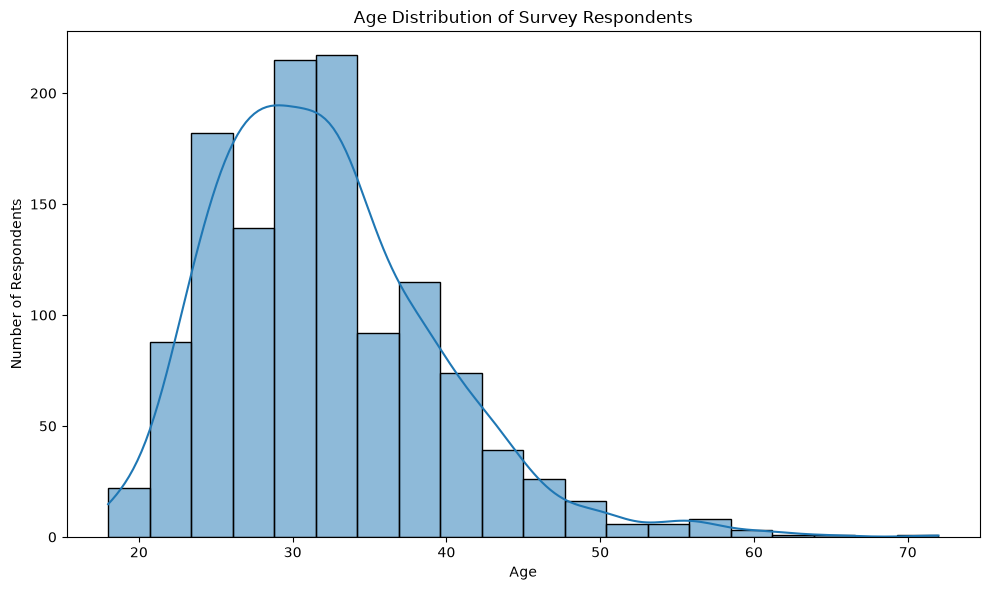

In [29]:
# Chart 1: Age Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="Age",
    bins=20,
    kde=True
)

plt.title("Age Distribution of Survey Respondents")
plt.xlabel("Age")
plt.ylabel("Number of Respondents")
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A histogram was selected to understand the distribution of respondent ages. Since age is a numerical variable, a histogram is appropriate for identifying the central concentration of respondents, the spread of ages, and whether there are unusually high or low age values.

2. **What is/are the insight(s) found from the chart?**

    The age distribution shows that the survey is concentrated largely among working-age technology professionals, with most respondents falling within the younger and middle adult age ranges. The distribution also shows that the dataset contains respondents across a relatively broad adult age range, approximately 18 to 72 years.

3. **Will the gained insights help creating a positive business impact?**

    Yes. Understanding the age composition helps organizations interpret the survey findings in the correct workforce context. However, age alone does not appear to be one of the strongest treatment-related factors in the analysis. Therefore, organizations should avoid designing mental-health interventions solely around age groups.

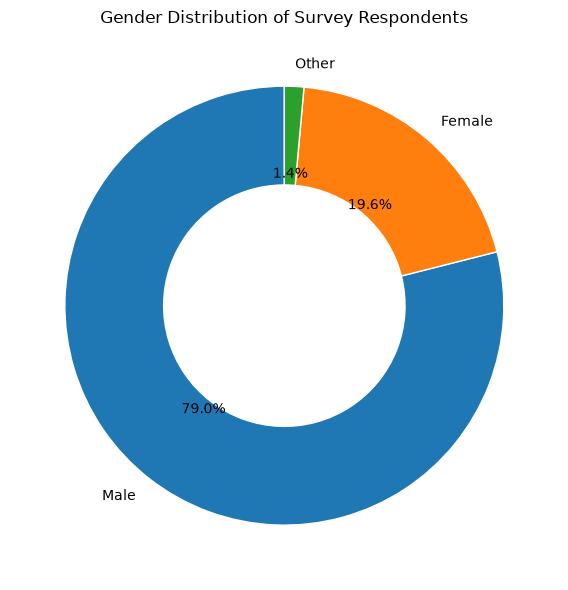

In [30]:
# Chart 2: Gender Distribution

gender_counts = df_clean["Gender"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45, "edgecolor": "white"}
)

plt.title("Gender Distribution of Survey Respondents")
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**
    
    A donut chart was selected because Gender is a categorical variable with a small number of categories. The chart clearly communicates the proportion of respondents belonging to each gender category and makes the overall composition of the survey population easy to understand.

2. **What is/are the insight(s) found from the chart?**
    
    The survey population is predominantly represented by male respondents, while female and other gender categories represent smaller portions of the dataset. Therefore, the overall results should be interpreted with awareness of the demographic composition of the survey.

    The analysis also found a statistically significant association between gender and treatment behavior, although the strength of the association is lower than the strongest factors identified in the analysis.

3. **Will the gained insights help creating a positive business impact?**
    
    Yes. Understanding demographic representation can help organizations ensure that mental-health programs are inclusive. A potential limitation is that smaller gender groups have fewer observations, so conclusions about those groups should be interpreted carefully.

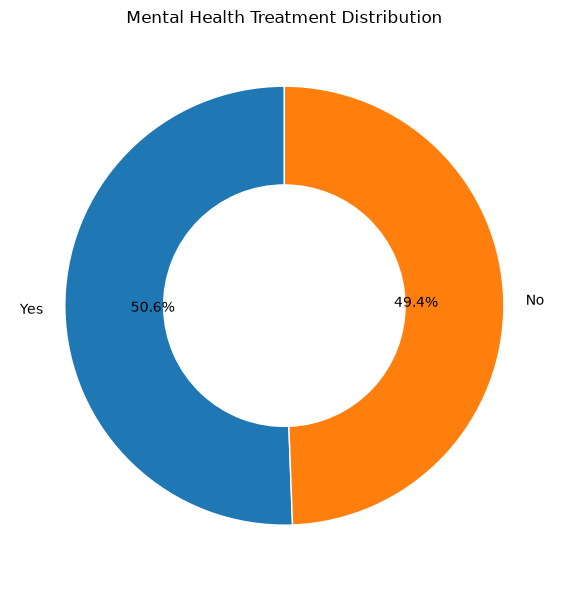

In [ ]:
# Chart 3: Mental Health Treatment Distribution

treatment_counts = df_clean["treatment"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    treatment_counts.values,
    labels=treatment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45, "edgecolor": "white"}
)

plt.title("Mental Health Treatment Distribution")
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A bar chart was selected to show the distribution of the main outcome variable, treatment. This establishes the overall treatment pattern before examining factors associated with it.

2. **What is/are the insight(s) found from the chart?**

    There are **637 respondents who reported treatment and 622 who reported no treatment**, resulting in an overall treatment rate of approximately **50.6%**.

    This means the treatment and non-treatment groups are relatively balanced, making treatment a useful outcome variable for comparative analysis.

3. **Will the gained insights help creating a positive business impact?**

    Yes. The finding provides a baseline for evaluating treatment-related gaps. The fact that almost half of respondents did not report treatment highlights the importance of understanding barriers to access, awareness, and help-seeking.

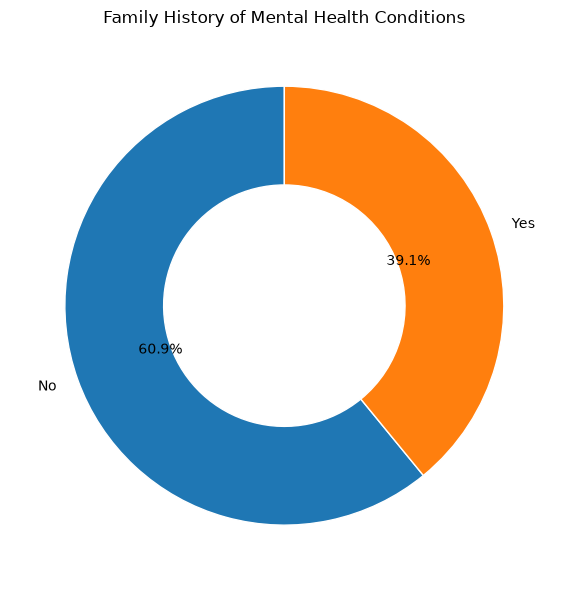

In [65]:
# Chart 4: Family History of Mental Health Conditions

family_counts = df_clean["family_history"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    family_counts.values,
    labels=family_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45, "edgecolor": "white"}
)

plt.title("Family History of Mental Health Conditions")
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A bar chart was selected to compare respondents with and without a reported family history of mental health conditions. Family history is an important personal factor that can be examined against treatment behavior.

2. **What is/are the insight(s) found from the chart?**

    Out of the 1,259 respondents, **492 reported a family history**, while **767 did not**.

    The treatment analysis shows a substantial difference between these groups. Respondents with a reported family history have a treatment rate of approximately **74.2%**, compared with approximately **35.5%** among respondents without one.

3. **Will the gained insights help creating a positive business impact?**

    Yes. Family history can be considered an important indicator when understanding treatment patterns. However, it should never be used to label or discriminate against employees. Organizations should use such insights to improve awareness and access to support rather than make assumptions about individual employees.

### B. Mental Health & Treatment Patterns

This section examines treatment-seeking behavior and family history of mental health conditions among survey respondents.

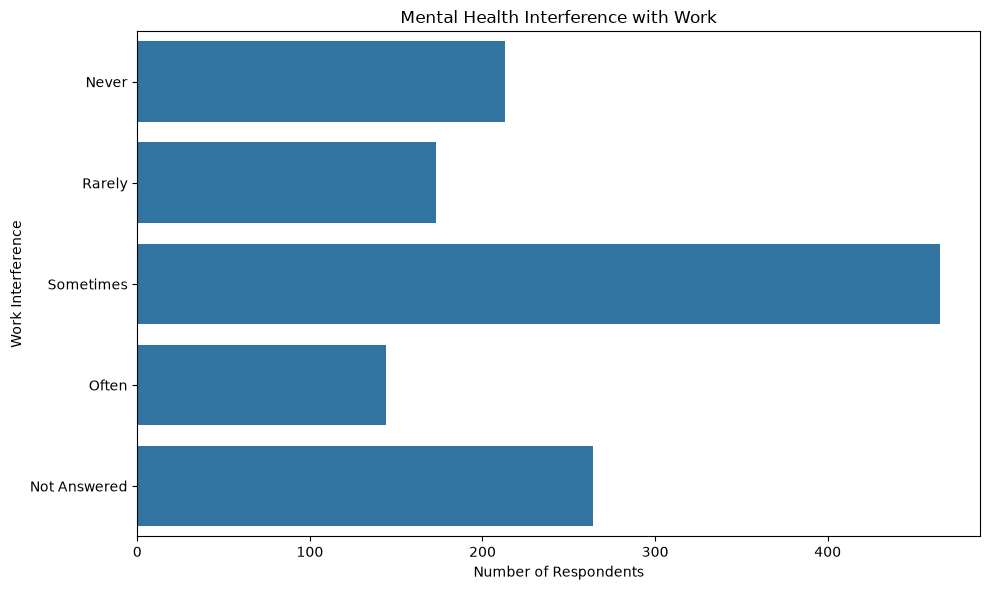

In [61]:
# Chart 5: Mental Health Interference with Work

work_order = [
    "Never",
    "Rarely",
    "Sometimes",
    "Often",
    "Not Answered"
]

work_counts = (
    df_clean["work_interfere"]
    .value_counts()
    .reindex(work_order)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=work_counts.values,
    y=work_counts.index
)

plt.title("Mental Health Interference with Work")
plt.xlabel("Number of Respondents")
plt.ylabel("Work Interference")
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A bar chart was selected to understand how frequently respondents reported that mental health interferes with their work. This variable directly connects mental-health experiences with workplace functioning.

2. **What is/are the insight(s) found from the chart?**

    The responses are distributed across **Never, Rarely, Sometimes, Often, and Not Answered**. Among the answered responses, "Sometimes" is the largest category, followed by "Never", "Rarely", and "Often".

    The presence of respondents reporting frequent work interference makes this variable particularly important for understanding treatment behavior.

3. **Will the gained insights help creating a positive business impact?**

    Yes. This insight can help organizations recognize that mental-health challenges can affect workplace functioning. It supports the need for confidential support, flexible resources, and early intervention.

    A negative business impact can occur when employees experience work interference but do not receive appropriate support, potentially affecting productivity, engagement, and retention.

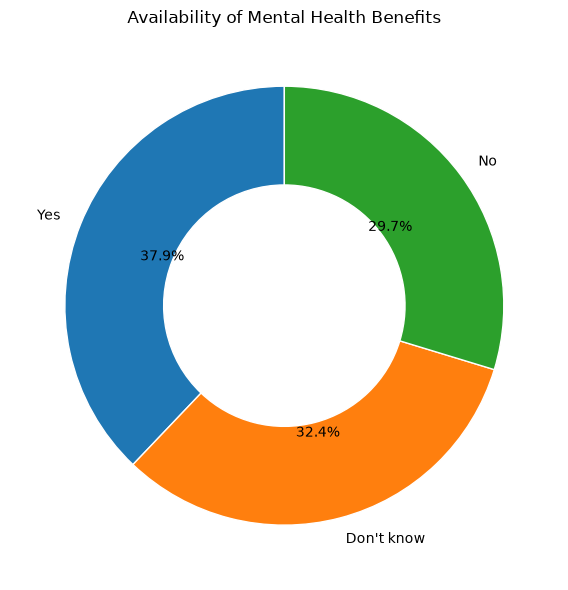

In [67]:
# Chart 6: Mental Health Benefits

benefit_counts = df_clean["benefits"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    benefit_counts.values,
    labels=benefit_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45, "edgecolor": "white"}
)

plt.title("Availability of Mental Health Benefits")
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A bar chart was selected to examine the availability of mental-health benefits reported by respondents. This is important because workplace benefits can influence employees' awareness and ability to access mental-health support.

2. **What is/are the insight(s) found from the chart?**

    Respondents reported different levels of access to mental-health benefits, with "Yes" representing the largest treatment-supporting category.

    The analysis shows that respondents reporting mental-health benefits have a treatment rate of approximately 63.94%, compared with a lower rate among respondents reporting no benefits or uncertainty.

3. **Will the gained insights help creating a positive business impact?**

    Yes. Organizations can improve employee support by making mental-health benefits more accessible, visible, and easier to understand.

    Clearly communicating available benefits can help reduce uncertainty and make it easier for employees to identify appropriate support resources.

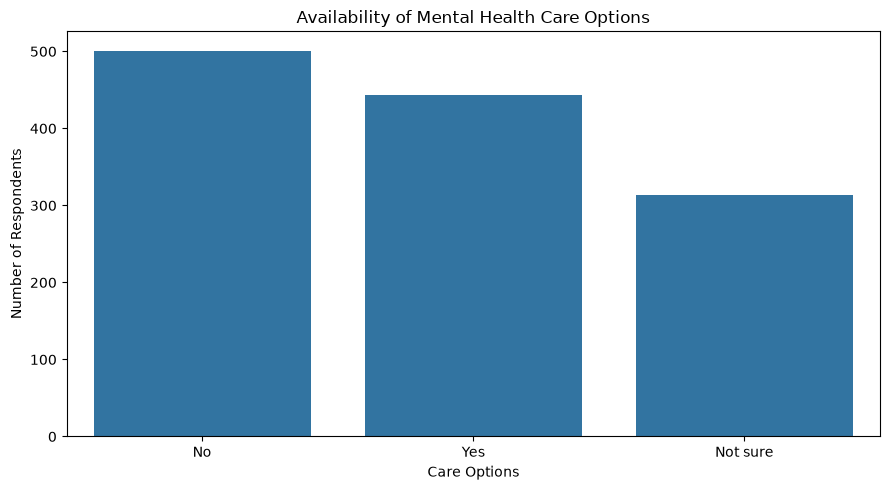

In [ ]:
# Chart 7: Mental Health Care Options

care_counts = df_clean["care_options"].value_counts()

plt.figure(figsize=(9, 5))

sns.barplot(
    x=care_counts.index,
    y=care_counts.values
)

plt.title("Availability of Mental Health Care Options")
plt.xlabel("Care Options")
plt.ylabel("Number of Respondents")

plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A bar chart was selected to examine respondents' perceptions of whether their workplace provides mental-health care options. Access to care is directly relevant to an employee's ability to seek professional support.

2. **What is/are the insight(s) found from the chart?**

    Respondents who reported "Yes" to having mental-health care options showed a substantially higher treatment rate than those reporting "No" or "Not sure."

    The treatment rate for respondents reporting care options was approximately 69.14%.

    Care options also showed a statistically significant association with treatment, with p < 0.001 and Cramér's V = 0.272.

3. **Will the gained insights help creating a positive business impact?**

    Yes. The finding highlights the importance of making mental-health care pathways visible and accessible.

    Organizations can improve support by clearly communicating available counseling, healthcare, EAP, or other confidential care resources.

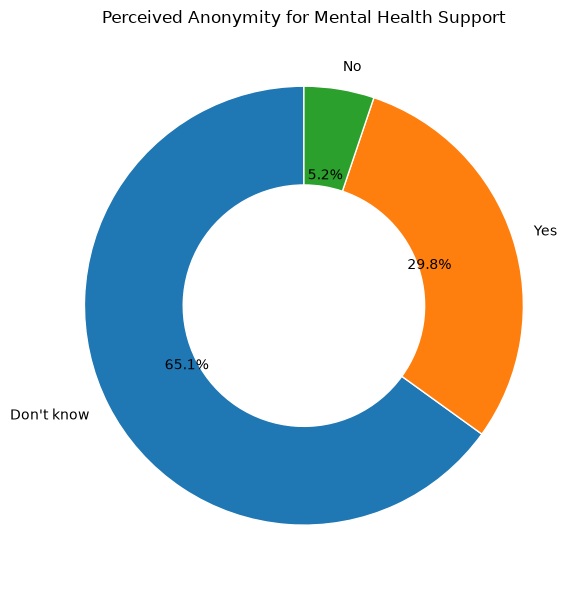

In [60]:
# Chart 8: Perceived Anonymity

anonymity_counts = df_clean["anonymity"].value_counts()

plt.figure(figsize=(8, 6))

plt.pie(
    anonymity_counts.values,
    labels=anonymity_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.45, "edgecolor": "white"}
)

plt.title("Perceived Anonymity for Mental Health Support")
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A bar chart was selected to examine how respondents perceive anonymity when seeking mental-health support at work.

    Confidentiality and anonymity are important workplace considerations because employees may hesitate to seek help if they are concerned about disclosure.

2. **What is/are the insight(s) found from the chart?**

    Respondents show different perceptions of workplace anonymity, including uncertainty.

    The analysis indicates that perceived anonymity has a statistically significant, although smaller, association with treatment behavior, with Cramér's V = 0.139.

3. **Will the gained insights help creating a positive business impact?**

    Yes. Organizations can strengthen trust by clearly communicating how employee mental-health information is handled.

    Employees should understand what information is confidential, who can access it, and how support can be obtained without unnecessary disclosure.

In [84]:
# Chart 9 — Worldwide Respondent Distribution

data = df_clean.copy()
data["Country"] = data["Country"].astype(str).str.strip()
data = data[~data["Country"].str.lower().isin(["", "unknown", "nan"])]

# Summarize country/state data
def summary(d, col):
    x = d.groupby(col)["treatment"].agg(
        Respondents="size",
        Treated=lambda x: (x == "Yes").sum()
    ).reset_index()
    x["Percentage of Total"] = x["Respondents"] / len(d) * 100
    x["Treatment Rate"] = x["Treated"] / x["Respondents"] * 100
    return x

country_map = summary(data, "Country")

states = """AL AK AZ AR CA CO CT DE FL GA HI ID IL IN IA KS KY LA ME MD MA MI MN
MS MO MT NE NV NH NJ NM NY NC ND OH OK OR PA RI SC SD TN TX UT VT VA
WA WV WI WY DC""".split()

usa = data[
    data["Country"].str.lower().isin(
        ["united states", "united states of america", "usa", "us"]
    )
].copy()

usa["state"] = usa["state"].astype(str).str.strip().str.upper()
state_map = summary(usa[usa["state"].isin(states)], "state")

# Create maps
world = px.choropleth(
    country_map,
    locations="Country",
    locationmode="country names",
    color="Respondents",
    hover_name="Country",
    color_continuous_scale="Teal",
    projection="natural earth"
)

us = px.choropleth(
    state_map,
    locations="state",
    locationmode="USA-states",
    color="Respondents",
    hover_name="state",
    color_continuous_scale="Teal",
    scope="usa"
)

# Hover details
hover = (
    "<b>%{hovertext}</b><br><br>"
    "Respondents: <b>%{customdata[0]:,}</b><br>"
    "% of Total Respondents: <b>%{customdata[1]:.2f}%</b><br>"
    "Treatment Rate: <b>%{customdata[2]:.2f}%</b><extra></extra>"
)

for fig, d in [(world, country_map), (us, state_map)]:
    fig.update_traces(
        customdata=d[["Respondents", "Percentage of Total", "Treatment Rate"]],
        hovertemplate=hover
    )

# Interactive World / USA view
fig = go.Figure(data=world.data + us.data)

world_layout = dict(
    title="Worldwide Distribution of Survey Respondents",
    geo=dict(scope="world", projection_type="natural earth",
             showland=True, showcountries=True,
             showcoastlines=True, showocean=True, showlakes=True)
)

usa_layout = dict(
    title="United States — State-Level Respondent Distribution",
    geo=dict(scope="usa", projection_type="albers usa",
             showland=True, showcountries=True,
             showcoastlines=True, showocean=True, showlakes=True)
)

fig.update_layout(
    **world_layout,
    height=700,
    margin=dict(l=10, r=10, t=90, b=10),
    updatemenus=[dict(
        type="buttons",
        direction="left",
        x=.5, xanchor="center", y=1.08,
        buttons=[
            dict(
                label="🌍 World View",
                method="update",
                args=[
                    {"visible": [True] * len(world.data) + [False] * len(us.data)},
                    world_layout
                ]
            ),
            dict(
                label="🇺🇸 USA State Detail",
                method="update",
                args=[
                    {"visible": [False] * len(world.data) + [True] * len(us.data)},
                    usa_layout
                ]
            )
        ]
    )],
    coloraxis_colorbar=dict(title="Respondents")
)

fig.show()

*Interactive world map showing respondent count, percentage of total respondents, and treatment rate, with U.S. state-level detail available when zoomed into the United States.*

1. **Why did you pick the specific chart?**

    A choropleth map was selected to visualize the geographic distribution of survey respondents. The interactive map provides both a worldwide view and a detailed United States state-level view, making it easier to identify where the survey responses are concentrated.

2. **What is/are the insight(s) found from the chart?**

    The worldwide view shows that the **United States has by far the highest number of survey respondents**, with substantially more responses than any other country represented in the dataset.

    The United States state-level view shows that respondents are distributed across many states, but the concentration is not uniform. **California has the highest number of respondents**, followed by several other states with comparatively higher response counts.

    The map also shows that some states have relatively few respondents or no recorded responses. Therefore, the geographic distribution of the dataset is heavily concentrated in the United States and should not be interpreted as a representation of global technology workers.

3. **Will the gained insights help creating a positive business impact?**

    Yes. Understanding the geographic distribution helps establish the coverage and limitations of the survey data. Organizations can use this information to identify regions that are well represented and recognize where additional data collection may be required.

    The major limitation is that the dataset is strongly concentrated in the United States. Therefore, conclusions from this survey should not automatically be generalized to technology employees worldwide.

### C. Demographic Factors and Mental Health Treatment

This section examines whether mental health treatment patterns differ across age, gender, and other respondent characteristics.

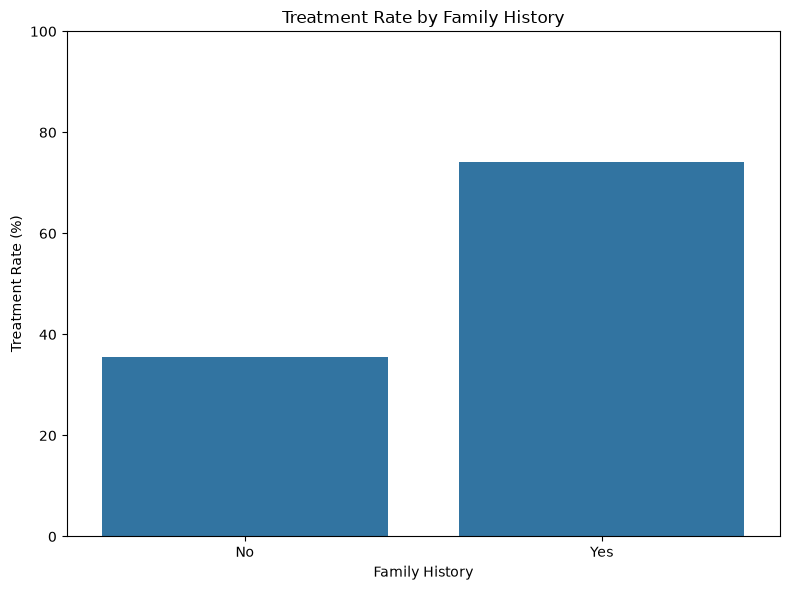

In [68]:
# Chart 10: Treatment Rate by Family History

family_treatment = (
    df_clean.groupby("family_history")["treatment"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Treatment Rate")
)

plt.figure(figsize=(8, 6))

sns.barplot(
    data=family_treatment,
    x="family_history",
    y="Treatment Rate"
)

plt.title("Treatment Rate by Family History")
plt.xlabel("Family History")
plt.ylabel("Treatment Rate (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A grouped treatment-rate chart was selected to directly compare treatment behavior between respondents with and without a reported family history. Percentages provide a fair comparison between groups of different sizes.

2. **What is/are the insight(s) found from the chart?**

    The treatment rate is approximately **74.2%** among respondents reporting a family history compared with approximately **35.5%** among those without a reported family history.

    This is a difference of roughly **38.7 percentage points**, making family history one of the strongest treatment-related patterns identified in the EDA.

    The statistical analysis also confirms a strong association between family history and treatment, with Cramér's V approximately **0.375**.

3. **Will the gained insights help creating a positive business impact?**

    Yes. Organizations can use this insight to emphasize mental-health awareness and make treatment resources easier to access. The negative implication is that family history must not be used as a basis for discrimination or assumptions about an employee's mental health. The analysis identifies an association, not a causal relationship.

### **D. Workplace Mental Health Support**

This section examines the availability of workplace mental health benefits, care options, wellness programs, help-seeking resources, anonymity, and leave policies, and their relationship with treatment-seeking behavior.

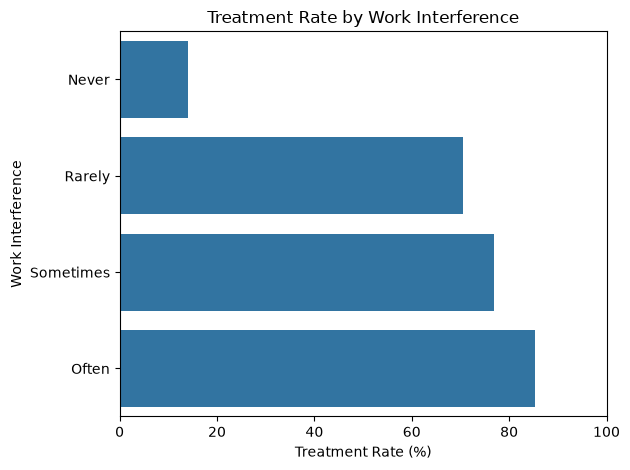

In [81]:
# Chart 11 — Treatment Rate by Work Interference

work_order = ["Never", "Rarely", "Sometimes", "Often"]

work_treatment = (
    df_clean[df_clean["work_interfere"].isin(work_order)]
    .groupby("work_interfere")["treatment"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reindex(work_order)
    .reset_index(name="Treatment Rate")
)

sns.barplot(
    data=work_treatment,
    x="Treatment Rate",
    y="work_interfere"
)

plt.title("Treatment Rate by Work Interference")
plt.xlabel("Treatment Rate (%)")
plt.ylabel("Work Interference")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A treatment-rate bar chart was selected to compare treatment-seeking behavior across different levels of work interference. This makes it easy to evaluate how treatment rates vary as mental health increasingly affects respondents' ability to work.

2. **What is/are the insight(s) found from the chart?**

    Work interference shows the strongest treatment-related pattern in the analysis.

    The treatment rate is approximately:

    - **Often: 85.4%**
    - **Sometimes: 77.0%**
    - **Rarely: 70.5%**
    - **Never: 14.1%**

    Respondents reporting that mental health often interferes with work have a treatment rate approximately **71 percentage points higher** than those reporting that it never interferes with work.

    The statistical analysis confirms a **strong association**, with Cramér's V approximately **0.542**.

3. **Will the gained insights help creating a positive business impact?**

    Yes. This is one of the most actionable findings in the analysis. Organizations can use these insights to identify employees experiencing greater work-related mental health difficulties and strengthen early support, awareness, and access to appropriate resources.

    From a business perspective, limited access to support may contribute to difficulties in maintaining productivity and employee well-being. However, this relationship should be interpreted as an **association rather than evidence that work interference causes treatment-seeking behavior**.

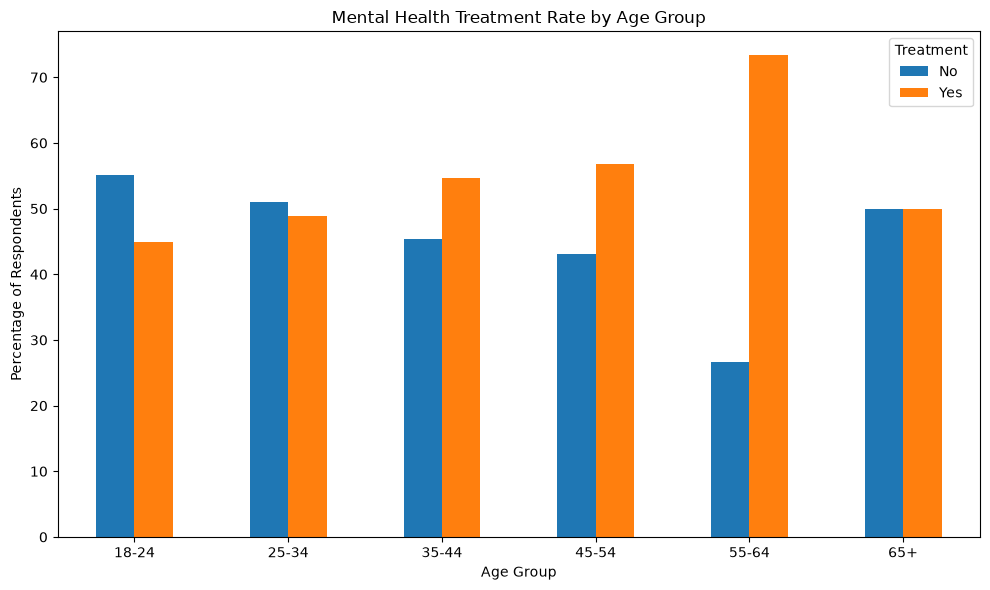

In [80]:
# Chart 12 — Treatment Rate by Age Group

age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

age_treatment = (
    pd.crosstab(
        df_clean["Age_Group"],
        df_clean["treatment"],
        normalize="index"
    )
    .mul(100)
    .reindex(index=age_order, columns=["No", "Yes"])
)

age_treatment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Mental Health Treatment Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Treatment")
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A grouped bar chart was selected to compare treatment rates across age groups. This helps determine whether treatment behavior changes substantially across different stages of the working population.

2. **What is/are the insight(s) found from the chart?**

    Treatment rates vary to some extent across age groups, but the statistical analysis indicates that the relationship between age group and treatment is **not statistically significant**.

    The p-value for age group was approximately **0.115**, which is above the conventional 0.05 significance threshold.

3. **Will the gained insights help creating a positive business impact?**

    Yes, mainly because it prevents over-prioritizing age as an intervention factor. The analysis suggests that organizations should focus more strongly on variables with demonstrated relationships to treatment, particularly work interference and family history.

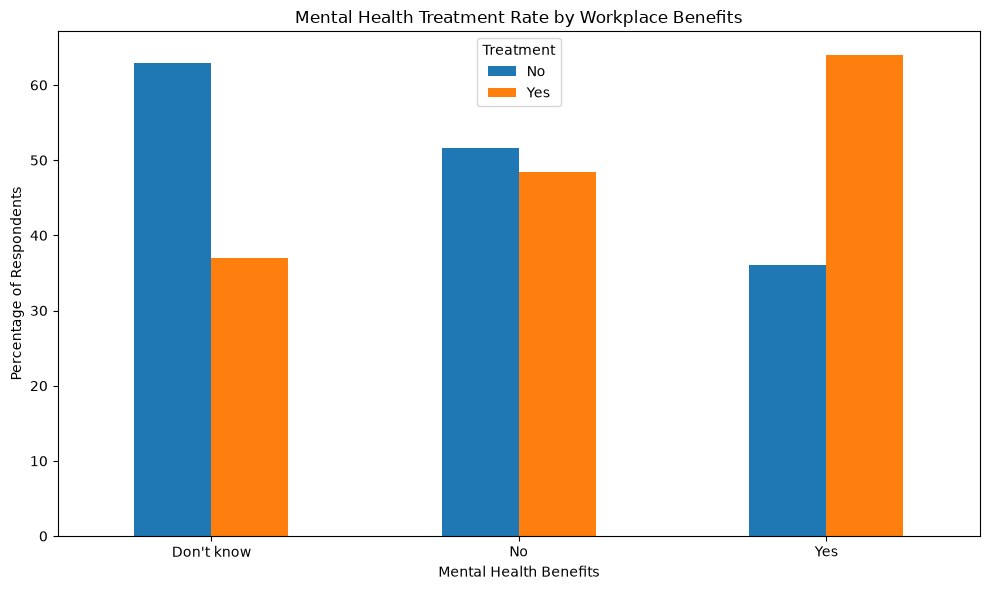

In [41]:
# Chart 13: Treatment Rate by Mental Health Benefits

benefits_treatment = pd.crosstab(
    df_clean["benefits"],
    df_clean["treatment"],
    normalize="index"
) * 100

benefits_treatment = benefits_treatment.reindex(
    columns=["No", "Yes"]
)

benefits_treatment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Mental Health Treatment Rate by Workplace Benefits")
plt.xlabel("Mental Health Benefits")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Treatment")

plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A grouped bar chart was selected to compare treatment rates according to the availability of workplace mental-health benefits. This directly evaluates whether treatment behavior differs across benefit-access groups.

2. **What is/are the insight(s) found from the chart?**

    Respondents reporting mental-health benefits have a treatment rate of approximately 63.94%.

    Treatment rates are lower among respondents reporting no benefits or uncertainty. The statistical analysis confirms a significant association between benefits and treatment, with p < 0.001 and Cramér's V = 0.223.

3. **Will the gained insights help creating a positive business impact?**

    Yes. Organizations can use this insight to review whether mental-health benefits are sufficiently available and clearly communicated.

    Improving awareness of existing benefits may help employees understand where and how they can obtain support.

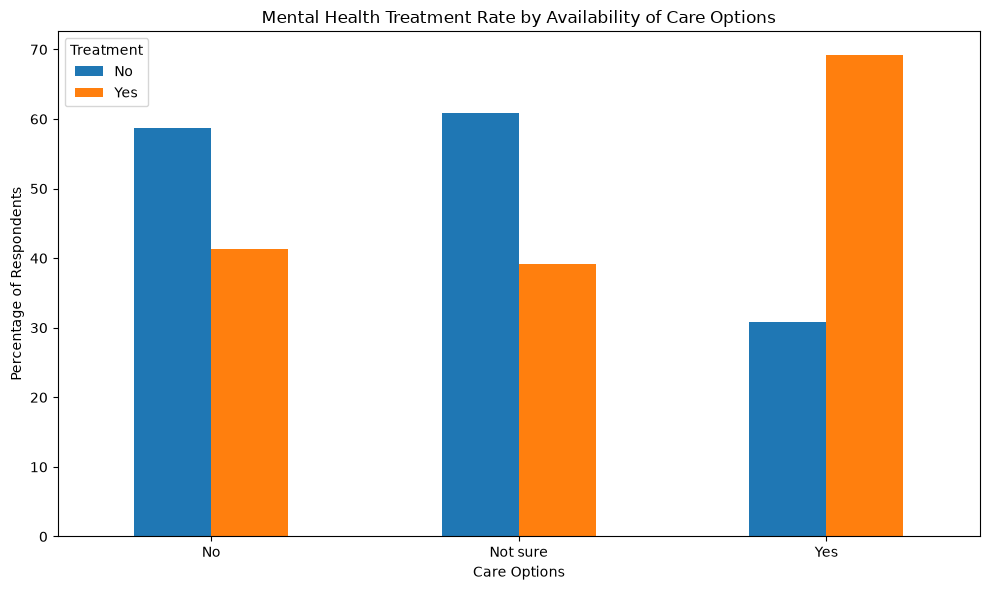

In [42]:
# Chart 14: Treatment Rate by Care Options

care_treatment = pd.crosstab(
    df_clean["care_options"],
    df_clean["treatment"],
    normalize="index"
) * 100

care_treatment = care_treatment.reindex(
    columns=["No", "Yes"]
)

care_treatment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Mental Health Treatment Rate by Availability of Care Options")
plt.xlabel("Care Options")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Treatment")

plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A grouped bar chart was selected to compare treatment rates across different levels of perceived access to mental-health care options.

2. **What is/are the insight(s) found from the chart?**

    Respondents reporting "Yes" to available care options have a treatment rate of approximately 69.14%.

    The treatment pattern differs substantially from respondents reporting no access or uncertainty.

    The relationship is statistically significant, with p < 0.001 and Cramér's V = 0.272, indicating a moderate association.

3. **Will the gained insights help creating a positive business impact?**

    Yes. Organizations can focus on making care pathways easier to discover and access.

    Clear communication about confidential counseling and professional support options can reduce uncertainty around where employees can seek help.

### E. Awareness, Confidentiality, and Workplace Culture

This section examines employee awareness of mental health resources, perceived confidentiality, access to leave, and attitudes toward discussing mental health in the workplace.

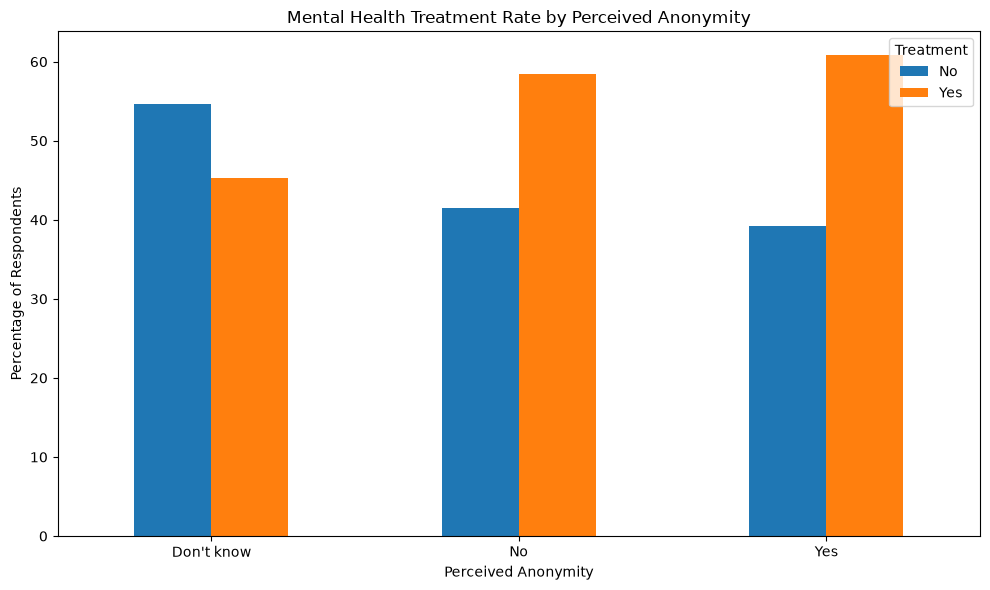

In [71]:
# Chart 15: Treatment Rate by Perceived Anonymity

anonymity_treatment = pd.crosstab(
    df_clean["anonymity"],
    df_clean["treatment"],
    normalize="index"
) * 100

anonymity_treatment = anonymity_treatment.reindex(
    columns=["No", "Yes"]
)

anonymity_treatment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Mental Health Treatment Rate by Perceived Anonymity")
plt.xlabel("Perceived Anonymity")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Treatment")

plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A grouped bar chart was selected to compare treatment rates across different perceptions of workplace anonymity.

    This directly examines whether perceived confidentiality is associated with differences in treatment behavior.

2. **What is/are the insight(s) found from the chart?**

    Treatment rates differ across anonymity categories.

    The statistical analysis indicates a significant association between perceived anonymity and treatment, although the effect size is relatively small, with Cramér's V = 0.139.

3. **Will the gained insights help creating a positive business impact?**

    Yes. The finding emphasizes the importance of employee trust.

    Organizations can improve confidence in mental-health support by clearly communicating confidentiality policies and minimizing unnecessary disclosure requirements.

### F. Workplace Culture and Mental Health Stigma

This section examines employee perceptions of coworkers, supervisors, interviews, and workplace consequences related to discussing mental health.

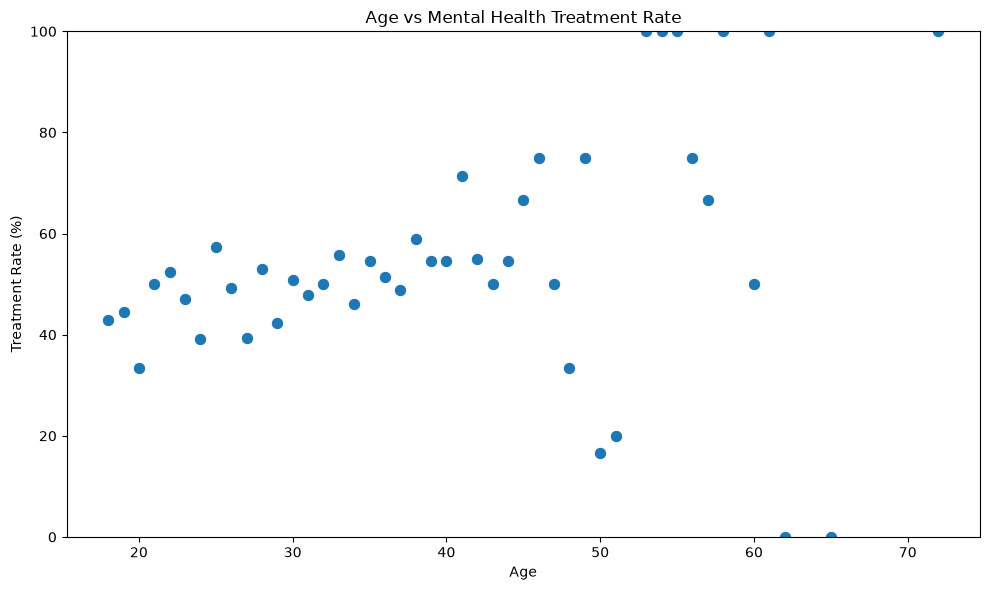

In [57]:
# Chart 16: Age vs Treatment Rate

age_treatment_scatter = (
    df_clean
    .groupby("Age")["treatment"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .reset_index(name="Treatment Rate")
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=age_treatment_scatter,
    x="Age",
    y="Treatment Rate",
    s=80
)

plt.title("Age vs Mental Health Treatment Rate")
plt.xlabel("Age")
plt.ylabel("Treatment Rate (%)")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A scatter plot was selected to examine the relationship between respondent age and mental health treatment rate. This chart helps identify whether treatment rates show any clear pattern as age increases.

2. **What is/are the insight(s) found from the chart?**

    The chart shows considerable variation in treatment rates across different age groups. Treatment rates are generally spread across the age range rather than following a consistent upward or downward pattern.

    Some older respondents show very high treatment rates, while others show very low or zero treatment rates. This indicates that age alone does not provide a clear explanation for differences in treatment behavior.

    Overall, there does not appear to be a strong linear relationship between age and treatment rate.

3. **Will the gained insights help creating a positive business impact?**

    Yes. The analysis suggests that organizations should not use age as the primary basis for identifying employees who may need mental health support.

    Instead, organizations can focus on stronger factors identified in the analysis, such as work interference, family history, and access to mental health care options.

    The main business benefit is avoiding age-based assumptions and ensuring that mental health resources remain available across different age groups.

In [78]:
# Chart 17 — Treatment Rate by Work Interference and Family History

work_order = ["Never", "Rarely", "Sometimes", "Often"]
family_order = ["No", "Yes"]

d = df[["work_interfere", "family_history", "treatment"]]
d = d[d["work_interfere"] != "Not Answered"].dropna().copy()

d["Treatment_Rate"] = d["treatment"].map({"No": 0, "Yes": 1})

d = (
    d.groupby(["work_interfere", "family_history"], as_index=False)
     .agg(Treatment_Rate=("Treatment_Rate", "mean"))
)
d["Treatment_Rate"] *= 100

fig = px.bar(
    d,
    x="work_interfere",
    y="Treatment_Rate",
    color="family_history",
    barmode="group",
    text="Treatment_Rate",
    category_orders={
        "work_interfere": work_order,
        "family_history": family_order
    },
    labels={
        "work_interfere": "Work Interference",
        "Treatment_Rate": "Treatment Rate (%)",
        "family_history": "Family History"
    },
    title="Treatment Rate by Work Interference and Family History",
    color_discrete_map={"No": "#A78BFA", "Yes": "#2DD4BF"}
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
    hovertemplate=(
        "<b>Work Interference:</b> %{x}<br>"
        "<b>Family History:</b> %{fullData.name}<br>"
        "<b>Treatment Rate:</b> %{y:.1f}%<extra></extra>"
    )
)

fig.update_layout(
    height=500,
    margin=dict(l=20, r=25, t=75, b=60),
    yaxis=dict(title="Treatment Rate (%)", range=[0, 100], ticksuffix="%"),
    xaxis=dict(title="Work Interference"),
    legend=dict(
        title="Family History",
        orientation="h",
        yanchor="bottom", y=1.02,
        xanchor="center", x=0.5
    )
)

fig.show()

1. **Why did you pick the specific chart?**

    A grouped bar chart was selected to compare mental health treatment rates across different levels of work interference while also considering family history of mental illness. This allows multiple factors to be examined together and provides a clearer multivariate view of treatment patterns.

2. **What is/are the insight(s) found from the chart?**

    Treatment rates increase substantially as the reported level of work interference increases. Among respondents **without a family history**, treatment rates range from **10.9% for Never** to **79.7% for Often**. Among respondents **with a family history**, treatment rates range from **28.9% for Never** to **90.0% for Often**.

    Respondents with a family history consistently show higher treatment rates across all work-interference levels. The largest difference is observed among respondents reporting **Rarely**, where treatment is **88.9% with a family history compared with 54.3% without one**.

3. **Will the gained insights help creating a positive business impact?**

    Yes. The findings indicate that both work interference and family history are important factors associated with treatment behavior. Organizations can use these insights to strengthen mental health awareness, early support, and access to care, particularly for employees experiencing difficulties that interfere with their work.

In [79]:
# Chart 18 — Treatment Rate by Mental Health Benefits and Care Options

benefits_order = ["No", "Don't know", "Yes"]
care_order = ["No", "Not sure", "Yes"]

d = df[["benefits", "care_options", "treatment"]].dropna().copy()
d["Treatment_Rate"] = d["treatment"].map({"No": 0, "Yes": 1})

d = (
    d.groupby(["benefits", "care_options"], as_index=False)
     .Treatment_Rate.mean()
)

d["Treatment_Rate"] *= 100

fig = px.bar(
    d,
    x="care_options",
    y="Treatment_Rate",
    color="benefits",
    barmode="group",
    text="Treatment_Rate",
    category_orders={
        "care_options": care_order,
        "benefits": benefits_order
    },
    labels={
        "care_options": "Mental Health Care Options",
        "Treatment_Rate": "Treatment Rate (%)",
        "benefits": "Mental Health Benefits"
    },
    title="Treatment Rate by Mental Health Benefits and Care Options",
    color_discrete_map={
        "No": "#A78BFA",
        "Don't know": "#94A3B8",
        "Yes": "#2DD4BF"
    }
)

fig.update_traces(
    texttemplate="%{text:.1f}%",
    textposition="outside",
    hovertemplate=(
        "<b>Care Options:</b> %{x}<br>"
        "<b>Mental Health Benefits:</b> %{fullData.name}<br>"
        "<b>Treatment Rate:</b> %{y:.1f}%<extra></extra>"
    )
)

fig.update_layout(
    height=500,
    margin=dict(l=20, r=25, t=85, b=65),
    yaxis=dict(title="Treatment Rate (%)", range=[0, 100], ticksuffix="%"),
    xaxis=dict(title="Mental Health Care Options"),
    legend=dict(
        title="Mental Health Benefits",
        orientation="h",
        yanchor="bottom", y=1.02,
        xanchor="center", x=0.5
    )
)

fig.show()

1. **Why did you pick the specific chart?**

    A grouped bar chart was selected to examine treatment rates across different levels of awareness of mental health care options while also considering the availability of workplace mental health benefits. This provides a multivariate view of how workplace support factors relate to treatment behavior.

2. **What is/are the insight(s) found from the chart?**

    Treatment rates generally increase when respondents report greater awareness of available mental health care options. Among respondents whose employers **provide mental health benefits**, the treatment rate increases from **48.9% when care options are reported as No** to **73.7% when care options are reported as Yes**.

    The highest treatment rate shown in the chart is **100.0%** among respondents who reported that their employer benefits were **Don't know** and that they knew the available care options. This result should be interpreted carefully because the size of individual groups may differ.

3. **Will the gained insights help creating a positive business impact?**

    Yes. The findings suggest that workplace mental health support is not only about providing benefits but also about making employees aware of the care options available to them. Organizations can create positive business impact by improving communication about mental health benefits, making care pathways easier to understand, and increasing awareness of available support resources.

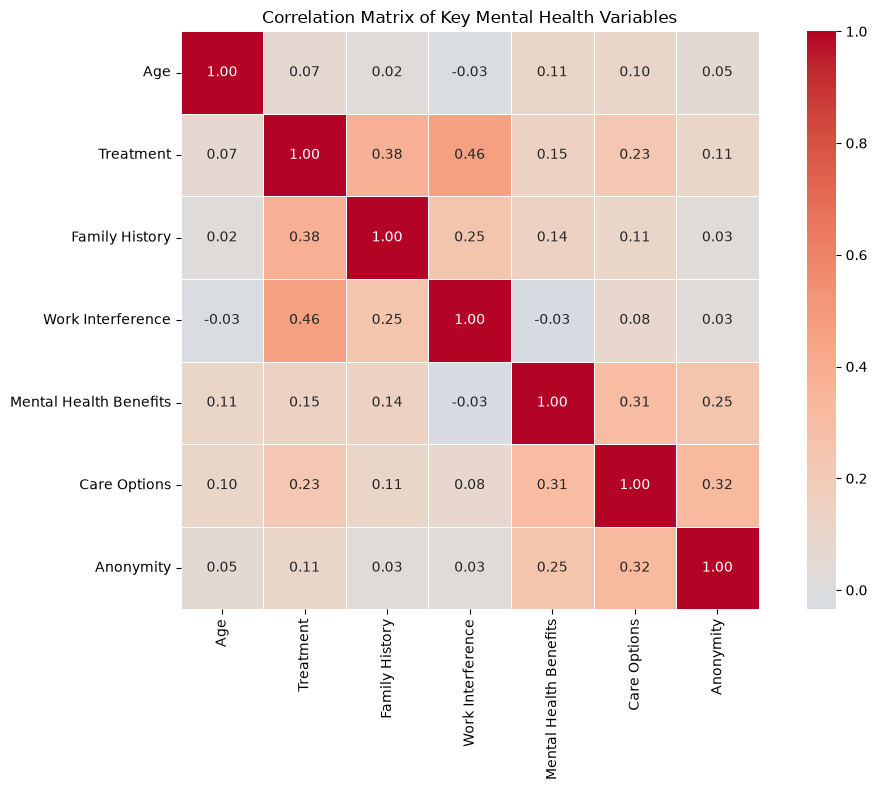

In [74]:
# Chart 19 - Correlation Matrix

encodings = {
    "Treatment": {"No": 0, "Yes": 1},
    "Family History": {"No": 0, "Yes": 1},
    "Work Interference": {
        "Never": 0, "Rarely": 1, "Sometimes": 2, "Often": 3
    },
    "Mental Health Benefits": {
        "No": 0, "Don't know": 0.5, "Yes": 1
    },
    "Care Options": {
        "No": 0, "Not sure": 0.5, "Yes": 1
    },
    "Anonymity": {
        "No": 0, "Don't know": 0.5, "Yes": 1
    }
}

correlation_data = pd.DataFrame({
    "Age": pd.to_numeric(df_clean["Age"], errors="coerce")
})

for column, mapping in encodings.items():
    source = {
        "Treatment": "treatment",
        "Family History": "family_history",
        "Work Interference": "work_interfere",
        "Mental Health Benefits": "benefits",
        "Care Options": "care_options",
        "Anonymity": "anonymity"
    }[column]

    correlation_data[column] = df_clean[source].map(mapping)

correlation_matrix = correlation_data.corr(method="spearman")

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Key Mental Health Variables")
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A correlation heatmap was selected to examine the strength and direction of relationships among the key numerical and encoded mental health variables. It provides a compact view of multiple relationships at the same time and helps identify which variables have stronger associations with mental health treatment.

2. **What is/are the insight(s) found from the chart?**

    The strongest correlation with **Treatment** is **Work Interference (0.46)**, followed by **Family History (0.38)**. This indicates that respondents experiencing greater work interference and those reporting a family history tend to show higher treatment values.

    Other positive relationships with Treatment are relatively weaker:

    - **Care Options:** 0.23
    - **Mental Health Benefits:** 0.15
    - **Anonymity:** 0.11
    - **Age:** 0.07

    The heatmap also shows a moderate relationship between **Care Options and Anonymity (0.32)** and between **Mental Health Benefits and Care Options (0.31)**.

    Age has very weak correlations with the other variables, suggesting that age does not have a strong linear relationship with the key mental health variables included in this analysis.

3. **Will the gained insights help creating a positive business impact?**

    Yes. The heatmap helps identify which factors are most closely associated with treatment behavior and can therefore help organizations prioritize areas for further investigation and support.

    The relatively stronger relationships between Treatment and Work Interference and between Treatment and Family History suggest that these areas deserve particular attention when designing mental health support strategies.

    The weaker correlations also provide useful information by showing that factors such as age and anonymity have comparatively weaker linear relationships with treatment in this dataset.

    However, correlation does not imply causation. The results represent relationships observed in the survey and should not be used to conclude that one factor directly causes another.

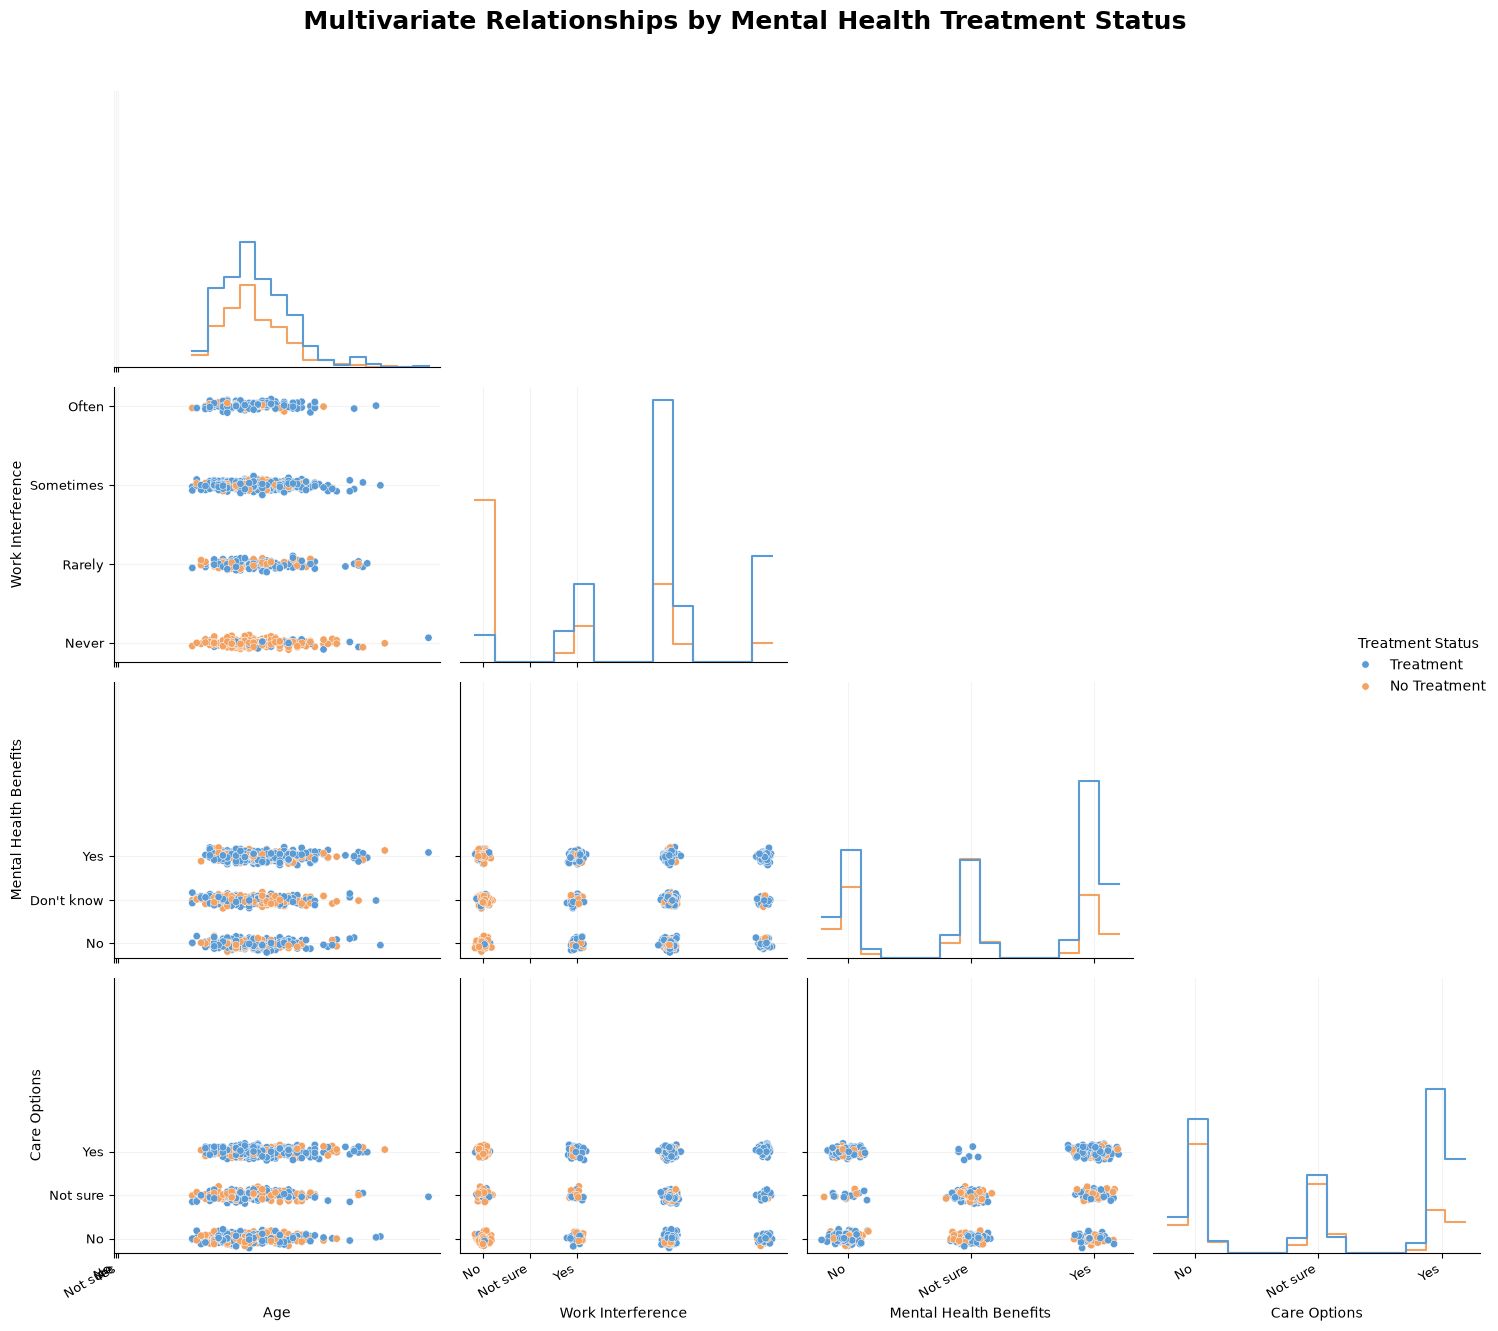

In [75]:
# Chart 20 - Multivariate Relationships

data = correlation_data[
    ["Age", "Treatment", "Work Interference", "Mental Health Benefits", "Care Options"]
].dropna().copy()

data["Treatment Label"] = data["Treatment"].map({
    0: "No Treatment", 1: "Treatment"
})

vars_ = ["Age", "Work Interference", "Mental Health Benefits", "Care Options"]

# Jitter categorical variables
rng = np.random.default_rng(42)
for col in vars_[1:]:
    data[col] += rng.normal(0, 0.035, len(data))

# Pair plot
g = sns.pairplot(
    data[vars_ + ["Treatment Label"]],
    vars=vars_,
    hue="Treatment Label",
    hue_order=["Treatment", "No Treatment"],
    palette={"Treatment": "#5B9BD5", "No Treatment": "#F4A261"},
    corner=True,
    diag_kind="hist",
    height=3.2,
    plot_kws={"alpha": 1, "s": 28, "edgecolor": "white", "linewidth": 0.35},
    diag_kws={"alpha": 1, "bins": 15, "element": "step", "fill": False}
)

g.fig.suptitle(
    "Multivariate Relationships by Mental Health Treatment Status",
    fontsize=18, fontweight="bold", y=1.02
)

labels = {
    "Work Interference": ([0, 1, 2, 3], ["Never", "Rarely", "Sometimes", "Often"]),
    "Mental Health Benefits": ([0, .5, 1], ["No", "Don't know", "Yes"]),
    "Care Options": ([0, .5, 1], ["No", "Not sure", "Yes"])
}

for i, col in enumerate(vars_):
    if col in labels:
        ticks, names = labels[col]
        for ax in list(g.axes[:, i]) + list(g.axes[i, :]):
            if ax is not None:
                ax.set_xticks(ticks)
                ax.set_xticklabels(names, rotation=30, ha="right", fontsize=8)
                ax.set_yticks(ticks)
                ax.set_yticklabels(names, fontsize=8)

for ax in g.axes.flat:
    if ax is not None:
        ax.grid(True, alpha=.15)
        ax.tick_params(labelsize=9)

g._legend.set_title("Treatment Status")
g.fig.set_size_inches(15, 13)
plt.tight_layout()
plt.show()

1. **Why did you pick the specific chart?**

    A multivariate pair plot was selected to examine relationships among multiple numerical and categorical variables simultaneously, while using mental health treatment status to distinguish between respondents who reported treatment and those who did not.

    The visualization helps compare patterns across **Age, Work Interference, Mental Health Benefits, and Care Options** and provides a broader view of how these variables interact with treatment status.

2. **What is/are the insight(s) found from the chart?**

    The chart shows two treatment groups:

    - **Blue:** Respondents who reported receiving mental health treatment.
    - **Orange:** Respondents who reported not receiving mental health treatment.
    - **Grey-looking areas:** These are not a separate category. They occur where the blue and orange distributions or data points overlap because the two groups are plotted on top of each other.

    Several patterns are visible:

    - The age distribution for both treatment groups is concentrated largely around the younger and middle adult age ranges.
    - Respondents reporting higher levels of work interference show a stronger presence of the treatment group.
    - Mental health benefits and care options show visible differences in the distribution of treatment and no-treatment respondents.
    - The overlap between the two groups also indicates that these variables do not perfectly separate respondents into treatment and no-treatment groups.

    The chart therefore provides a multivariate view of the same broader patterns identified in the individual analyses, particularly the stronger relationship between **work interference and treatment behavior**.

3. **Will the gained insights help creating a positive business impact?**

    Yes. The multivariate view helps organizations understand that mental health treatment behavior is associated with several workplace and personal factors rather than a single characteristic.

    The strongest practical insight is the visible relationship between work interference and treatment behavior, while workplace benefits and care options also provide useful context.

    The grey overlapping areas should not be interpreted as a third treatment category. They simply represent observations from the **Treatment** and **No Treatment** groups occupying similar areas of the visualization.

    These findings can help organizations design broader mental-health support strategies. However, the chart shows associations within an observational survey and should not be interpreted as evidence of causation.

## 5. ***Statistical Validation***

The exploratory analysis identified several relationships between workplace factors and mental health treatment.

To determine whether these relationships are statistically significant, Chi-square tests of independence are applied to categorical variables. Cramér's V is also calculated to measure the strength of association.

A statistically significant result indicates an association between variables, but it does not establish causation.

In [49]:
# Statistical Validation: Chi-square Test and Cramer's V

from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np


def cramers_v(table):
    """
    Calculate Cramer's V for a contingency table.
    """
    chi2, p, dof, expected = chi2_contingency(table)

    n = table.to_numpy().sum()
    rows, cols = table.shape

    phi2 = chi2 / n

    # Bias correction
    phi2_corrected = max(
        0,
        phi2 - ((cols - 1) * (rows - 1)) / (n - 1)
    )

    rows_corrected = rows - (
        ((rows - 1) ** 2) / (n - 1)
    )

    cols_corrected = cols - (
        ((cols - 1) ** 2) / (n - 1)
    )

    denominator = min(
        cols_corrected - 1,
        rows_corrected - 1
    )

    if denominator <= 0:
        return np.nan

    return np.sqrt(phi2_corrected / denominator)


def chi_square_analysis(df, feature, target="treatment"):
    """
    Perform Chi-square test and calculate Cramer's V.
    """

    table = pd.crosstab(
        df[feature],
        df[target]
    )

    chi2, p_value, dof, expected = chi2_contingency(table)

    v = cramers_v(table)

    return {
        "Feature": feature,
        "Chi-Square": chi2,
        "p-value": p_value,
        "Cramer's V": v,
        "Significant": "Yes" if p_value < 0.05 else "No"
    }


features_to_test = [
    "family_history",
    "work_interfere",
    "Gender",
    "Age_Group",
    "Company_Size_Group",
    "Remote_Work_Status",
    "benefits",
    "care_options",
    "wellness_program",
    "seek_help",
    "anonymity",
    "leave",
    "mental_health_consequence",
    "phys_health_consequence",
    "coworkers",
    "supervisor",
    "mental_health_interview",
    "phys_health_interview",
    "mental_vs_physical",
    "obs_consequence"
]


results = []

for feature in features_to_test:
    results.append(
        chi_square_analysis(
            df_clean,
            feature
        )
    )


stats_results = pd.DataFrame(results)

stats_results = stats_results.sort_values(
    by="p-value"
)

stats_results

,Feature,Chi-Square,p-value,Cramer's V,Significant
1,work_interfere,594.924318,1.944084e-127,0.685369,Yes
0,family_history,178.266767,1.158418e-40,0.375381,Yes
7,care_options,94.758727,2.650965e-21,0.271540,Yes
6,benefits,64.838590,8.326817e-15,0.223495,Yes
2,Gender,54.249161,1.659374e-12,0.203795,Yes
19,obs_consequence,30.139513,4.020553e-08,0.152193,Yes
10,anonymity,26.421892,1.830455e-06,0.139327,Yes
11,leave,29.943497,5.025795e-06,0.143598,Yes
12,mental_health_consequence,22.327285,1.418051e-05,0.127111,Yes
18,mental_vs_physical,17.458125,1.618141e-04,0.110845,Yes


Work interference has by far the strongest association with mental-health treatment.

#### A. Statistical Validation of Key Relationships

The initial Chi-square analysis identified several strong associations with mental health treatment.

Because missing responses in `work_interfere` were represented as `Not Answered` for descriptive analysis, the statistical validation is repeated using valid responses only. This avoids treating missing responses as a meaningful behavioral category.

Cramér's V is used to assess the strength of association, while statistical significance is evaluated using the p-value.

In [50]:
# Validate the strongest relationships using valid responses

from scipy.stats import chi2_contingency
import numpy as np
import pandas as pd


def calculate_association(df, feature, target="treatment"):
    
    analysis_df = df[[feature, target]].copy()
    
    # Remove missing values
    analysis_df = analysis_df.dropna()
    
    # Remove descriptive placeholder for missing work_interfere responses
    if feature == "work_interfere":
        analysis_df = analysis_df[
            analysis_df[feature] != "Not Answered"
        ]
    
    table = pd.crosstab(
        analysis_df[feature],
        analysis_df[target]
    )
    
    chi2, p_value, dof, expected = chi2_contingency(table)
    
    n = table.to_numpy().sum()
    rows, cols = table.shape
    
    phi2 = chi2 / n
    
    phi2_corrected = max(
        0,
        phi2 - ((cols - 1) * (rows - 1)) / (n - 1)
    )
    
    rows_corrected = rows - (
        ((rows - 1) ** 2) / (n - 1)
    )
    
    cols_corrected = cols - (
        ((cols - 1) ** 2) / (n - 1)
    )
    
    denominator = min(
        cols_corrected - 1,
        rows_corrected - 1
    )
    
    cramers_v_value = np.sqrt(
        phi2_corrected / denominator
    )
    
    return {
        "Feature": feature,
        "Valid Respondents": n,
        "Chi-Square": chi2,
        "p-value": p_value,
        "Cramer's V": cramers_v_value
    }


key_features = [
    "work_interfere",
    "family_history",
    "care_options",
    "benefits",
    "Gender",
    "anonymity",
    "leave",
    "mental_health_consequence",
    "mental_health_interview"
]


validated_results = pd.DataFrame(
    [
        calculate_association(
            df_clean,
            feature
        )
        for feature in key_features
    ]
)


validated_results = validated_results.sort_values(
    by="p-value"
)


validated_results

,Feature,Valid Respondents,Chi-Square,p-value,Cramer's V
0,work_interfere,995,294.837430,1.303354e-63,0.541845
1,family_history,1259,178.266767,1.158418e-40,0.375381
2,care_options,1259,94.758727,2.650965e-21,0.271540
3,benefits,1259,64.838590,8.326817e-15,0.223495
4,Gender,1259,54.249161,1.659374e-12,0.203795
5,anonymity,1259,26.421892,1.830455e-06,0.139327
6,leave,1259,29.943497,5.025795e-06,0.143598
7,mental_health_consequence,1259,22.327285,1.418051e-05,0.127111
8,mental_health_interview,1259,12.690159,1.755363e-03,0.092176


## 6. ***Key Analytical Insights***

The exploratory and statistical analyses reveal several important patterns in the mental health experiences of technology-sector employees.

1. **Work interference has the strongest association with treatment.**

    Work interference shows the strongest association with mental health treatment among the factors tested. After excluding unanswered responses, the Chi-square test remains highly significant (p < 0.001), with a Cramér's V of 0.542.

    This indicates a strong relationship between the frequency with which mental health interferes with work and treatment status.

2. **Family history is strongly associated with treatment.**
    Family history shows a statistically significant and moderate association with treatment (Cramér's V = 0.375, p < 0.001).

    Respondents reporting a family history of mental health conditions show substantially different treatment patterns from those without a reported family history.

3. **Access to mental health care options is associated with treatment.**

    Care options show a statistically significant moderate association with treatment (Cramér's V = 0.272, p < 0.001).

    Respondents reporting access to care options have a higher treatment rate than respondents reporting no access or uncertainty.

4. **Mental health benefits are associated with treatment.**

    The availability of workplace mental health benefits is significantly associated with treatment status (Cramér's V = 0.223, p < 0.001).

    This suggests that workplace benefits may be an important component of an environment that supports treatment-seeking.

5. **Gender is associated with treatment status.**

    Gender shows a statistically significant association with treatment (Cramér's V = 0.204, p < 0.001).

    However, differences across smaller gender categories should be interpreted cautiously because the number of respondents in those categories is relatively small.

6. **Awareness and perceived confidentiality matter.**

    Anonymity and perceived workplace consequences both show statistically significant, although smaller, associations with treatment.

    The large proportion of respondents selecting "Don't know" for several workplace-support questions also highlights an important awareness gap.

7. **Not every workplace factor is associated with treatment**

    The statistical analysis found no significant association between treatment and several variables, including age group, remote work status, company size, supervisor attitude, physical health interview perception, and physical health consequences.

    This distinction helps focus recommendations on the factors most strongly supported by the data.

#### Analytical Limitation

These findings describe associations within the survey data and do not establish causation. The survey is observational, and treatment status may be influenced by multiple interacting personal and workplace factors.

## ***7. Analysis Summary***

The following analysis summarizes the strongest treatment-related patterns identified during the EDA and statistical validation.

In [ ]:
# Analysis Summary: Treatment Rates

summary_features = [
    "family_history",
    "work_interfere",
    "benefits",
    "care_options",
    "anonymity",
    "leave",
    "mental_health_consequence"
]

summary_results = []

for feature in summary_features:

    temp = df_clean[[feature, "treatment"]].copy()

    temp = temp.dropna()

    if feature == "work_interfere":
        temp = temp[
            temp[feature] != "Not Answered"
        ]

    treatment_rate = (
        temp.groupby(feature)["treatment"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .reset_index(name="Treatment_Rate_%")
    )

    treatment_rate["Feature"] = feature

    treatment_rate = treatment_rate.rename(
        columns={feature: "Category"}
    )

    summary_results.append(treatment_rate)


executive_summary = pd.concat(
    summary_results,
    ignore_index=True
)

executive_summary = executive_summary[
    [
        "Feature",
        "Category",
        "Treatment_Rate_%"
    ]
]

executive_summary = executive_summary.sort_values(
    ["Feature", "Treatment_Rate_%"],
    ascending=[True, False]
)

executive_summary

,Feature,Category,Treatment_Rate_%
14,anonymity,Yes,60.800000
13,anonymity,No,58.461538
12,anonymity,Don't know,45.299145
8,benefits,Yes,63.941300
7,benefits,No,48.395722
6,benefits,Don't know,37.009804
11,care_options,Yes,69.144144
9,care_options,No,41.317365
10,care_options,Not sure,39.171975
1,family_history,Yes,74.186992


## ***8. Executive Summary***

The analysis identifies work interference, family history, and access to workplace mental health resources as the strongest factors associated with treatment status.

The findings suggest that organizations can potentially strengthen mental health support by improving access to care, increasing awareness of available benefits and resources, and creating workplace environments where employees feel comfortable seeking help.

These findings represent associations within the survey data and should not be interpreted as causal relationships.

In [52]:
# Executive Summary Metrics

overall_treatment_rate = (
    (df_clean["treatment"] == "Yes").mean() * 100
)

work_often_rate = (
    df_clean.loc[
        df_clean["work_interfere"] == "Often",
        "treatment"
    ].eq("Yes").mean() * 100
)

work_never_rate = (
    df_clean.loc[
        df_clean["work_interfere"] == "Never",
        "treatment"
    ].eq("Yes").mean() * 100
)

family_yes_rate = (
    df_clean.loc[
        df_clean["family_history"] == "Yes",
        "treatment"
    ].eq("Yes").mean() * 100
)

family_no_rate = (
    df_clean.loc[
        df_clean["family_history"] == "No",
        "treatment"
    ].eq("Yes").mean() * 100
)

care_yes_rate = (
    df_clean.loc[
        df_clean["care_options"] == "Yes",
        "treatment"
    ].eq("Yes").mean() * 100
)

benefits_yes_rate = (
    df_clean.loc[
        df_clean["benefits"] == "Yes",
        "treatment"
    ].eq("Yes").mean() * 100
)


executive_metrics = pd.DataFrame({
    "Metric": [
        "Overall Treatment Rate",
        "Treatment Rate - Work Interference: Often",
        "Treatment Rate - Work Interference: Never",
        "Treatment Rate - Family History: Yes",
        "Treatment Rate - Family History: No",
        "Treatment Rate - Care Options: Yes",
        "Treatment Rate - Benefits: Yes"
    ],
    
    "Value (%)": [
        overall_treatment_rate,
        work_often_rate,
        work_never_rate,
        family_yes_rate,
        family_no_rate,
        care_yes_rate,
        benefits_yes_rate
    ]
})

executive_metrics

,Metric,Value (%)
0,Overall Treatment Rate,50.595711
1,Treatment Rate - Work Interference: Often,85.416667
2,Treatment Rate - Work Interference: Never,14.084507
3,Treatment Rate - Family History: Yes,74.186992
4,Treatment Rate - Family History: No,35.462842
5,Treatment Rate - Care Options: Yes,69.144144
6,Treatment Rate - Benefits: Yes,63.941300


In [53]:
# Save final cleaned and feature-engineered dataset

from pathlib import Path

output_dir = Path("../outputs/cleaned_data")
output_dir.mkdir(parents=True, exist_ok=True)

final_path = output_dir / "mental_health_tech_final.csv"

df_clean.to_csv(
    final_path,
    index=False
)

print("Final dataset saved successfully:")
print(final_path.resolve())

print("\nFinal Shape:", df_clean.shape)

print("\nFinal Columns:")
print(df_clean.columns.tolist())

Final dataset saved successfully:
D:\Mental-Health-in-Tech-Analytics\outputs\cleaned_data\mental_health_tech_final.csv

Final Shape: (1259, 33)

Final Columns:
['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed', 'family_history', 'treatment', 'work_interfere', 'no_employees', 'remote_work', 'tech_company', 'benefits', 'care_options', 'wellness_program', 'seek_help', 'anonymity', 'leave', 'mental_health_consequence', 'phys_health_consequence', 'coworkers', 'supervisor', 'mental_health_interview', 'phys_health_interview', 'mental_vs_physical', 'obs_consequence', 'comments', 'Age_Group', 'Company_Size_Group', 'Remote_Work_Status', 'Mental_Health_History', 'Treatment_Status', 'Work_Interference_Level']


## ***9. Solution to Business Objective***

#### What do you suggest the client to achieve Business Objective? Explain Briefly.

Based on the EDA and statistical analysis, I recommend that organizations focus on improving **accessibility, awareness, confidentiality, and early support** rather than relying primarily on demographic characteristics.

The strongest treatment-related pattern is **work interference**. Respondents reporting that mental health often interferes with work have an approximately **85.4% treatment rate**, compared with approximately **14.1%** among those reporting that it never interferes. This indicates that employees experiencing a stronger workplace impact are substantially more likely to report treatment.

Family history is another important factor, with treatment rates of approximately **74.2%** among respondents reporting a family history compared with approximately **35.5%** among those without one.

Therefore, organizations should:

1. **Improve access to mental-health care** by making available resources easy to find and use.

2. **Increase awareness of mental-health benefits and care options** so employees understand what support is available.

3. **Provide confidential and psychologically safe support channels** to reduce concerns around discussing mental health.

4. **Train managers and supervisors** to recognize workplace challenges and respond appropriately without stigmatizing employees.

5. **Support employees experiencing work interference** through flexible and confidential pathways to professional help.

6. **Review mental-health benefits, wellness programs, and leave policies** to identify gaps in practical support.

7. **Monitor treatment-access patterns over time** using data while protecting employee privacy.

At the same time, demographic variables such as age group, remote work, and company size should not be treated as primary predictors because the statistical analysis did not find significant associations with treatment for these factors.

The recommendations should be interpreted carefully because the dataset is observational. The analysis identifies associations and patterns rather than proving that one factor causes another.

# **Conclusion**

The Mental Health in Tech Analytics project examined the 2014 Mental Health in Tech Survey containing **1,259 respondents** to understand mental-health treatment patterns and their relationship with demographic, personal, and workplace factors.

The analysis found an overall treatment rate of approximately **50.6%**, with 637 respondents reporting treatment and 622 reporting no treatment.

Among the variables analyzed, **work interference and family history emerged as the strongest treatment-related factors**. Respondents reporting that mental health often interferes with their work had an approximately **85.4% treatment rate**, compared with approximately **14.1%** among respondents reporting that it never interferes. Family history also showed a substantial difference, with approximately **74.2%** treatment among respondents reporting a family history compared with approximately **35.5%** among those without one.

Workplace support variables such as mental-health benefits and care options also showed meaningful differences in treatment behavior. Statistical analysis supported several of the major patterns identified through EDA, with work interference showing the strongest association, followed by family history, care options, benefits, and gender.

In contrast, factors such as **age group, remote work, company size, and supervisor attitudes** did not show statistically significant associations with treatment in this dataset.

The key business takeaway is that organizations should focus on making mental-health resources **accessible, confidential, visible, and easy to use**, particularly for employees experiencing mental-health challenges that interfere with work.

Finally, the findings represent relationships observed within an observational survey. Therefore, they should be interpreted as **associations rather than causal effects**. The analysis can guide workplace support strategies and further investigation, but it should not be used to make assumptions or decisions about individual employees.